# **Projekt 3: Klasyfikacja sentymentu na zbiorze IMDB - Ewolucja architektur NLP**

**Przedmiot:** Wprowadzenie do sieci neuronowych  

**Wykonali:** Mateusz Panek, Piotr Jasiak  

---

## 1. Wstęp
Niniejszy projekt stanowi zwieńczenie i podsumowanie naszego kursu. W poprzednich iteracjach (projekty Dry Bean Dataset oraz FER2013) z sukcesem implementowaliśmy modele w pełni połączone (MLP) do danych tabelarycznych oraz sieci konwolucyjne (CNN) do analizy obrazów. Obecny projekt otwiera przed nami trzeci wielki dział głębokiego uczenia: **Przetwarzanie Języka Naturalnego (NLP)** i analizę danych sekwencyjnych.

### Cel Badawczy
Naszym zadaniem jest zbudowanie klasyfikatora sentymentu (pozytywny/negatywny) dla recenzji filmowych ze słynnego zbioru **IMDB Dataset**. Zamiast jednak ograniczać się do jednego modelu, przeprowadzimy **szeroką analizę porównawczą**, która odzwierciedla historyczny rozwój architektury sieci neuronowych. Zestawimy ze sobą:
1. **Klasyczne podejście rekurencyjne (Vanilla RNN):** Jako baseline i dowód na istnienie problemu znikającego gradientu.
2. **Sieć Long Short-Term Memory (LSTM):** Rozwiązanie wprowadzające bramki pamięciowe (Forget, Input, Output gates), radzące sobie z długimi sekwencjami tekstu.
3. **Autorski Mini-Transformer:** Model oparty wyłącznie na zrównoleglonym mechanizmie atencji (*Self-Attention*), zbudowany przez nas od podstaw.
4. **Transfer Learning (LLM):** Pretrenowany model DistilBERT z platformy Hugging Face, prezentujący potęgę gigantycznych modeli językowych poddanych procesowi fine-tuningu.

Wzorując się na rygorze badawczym z naszych poprzednich projektów, każdy eksperyment zwieńczony zostanie dogłębną analizą wizualną (krzywe uczenia, macierze błędów) oraz wglądem w wewnętrzny proces decyzyjny sieci, ze szczególnym uwzględnieniem map ciepła (heatmap) dla mechanizmu atencji.

## 2. Inicjalizacja środowiska
Wczytanie niezbędnych bibliotek do manipulacji tensorami (PyTorch), przetwarzania tekstu (HuggingFace Datasets) oraz zaawansowanej wizualizacji (Seaborn, Matplotlib, WordCloud).

In [ ]:
!pip uninstall pandas datasets -y -q
!pip install pandas==2.2.2 datasets -q
!pip install transformers wordcloud -q

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from collections import Counter
import re
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import classification_report, confusion_matrix
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from tqdm.auto import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=4822):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(4822)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Aktywne urządzenie obliczeniowe: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'Model karty graficznej: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.4 MB/s eta 0:00:00
Aktywne urządzenie obliczeniowe: cuda
Model karty graficznej: Tesla T4


## 3. Przygotowanie danych

W tym kroku pobieramy zbiór danych i dzielimy go na trzy osobne części. Aby zachować sprawiedliwe warunki dla modeli, stosujemy **podział stratyfikowany**.

Oryginalny zbiór IMDB jest idealnie równy - zawiera dokładnie po 50% recenzji pozytywnych i negatywnych. Stratyfikacja daje nam gwarancję, że nasze podzbiory również zachowają tę proporcję (dokładnie 50:50). Dzięki temu modele nauczą się obu klas po równo i nie będą żadnej faworyzować.

**Strategia podziału danych:**
* **Zbiór treningowy (Train) - 20 000 recenzji:** Wykorzystywany bezpośrednio do uczenia modeli i aktualizacji ich wag. To na nim zostanie przeprowadzona pełna analiza EDA.
* **Zbiór walidacyjny (Validation) - 2 500 recenzji:** Niezależny zbiór służący do monitorowania miar dopasowania w trakcie uczenia.
* **Zbiór testowy (Test) - 2 500 recenzji:** Całkowicie odizolowany podzbiór, który zostanie użyty do ostatecznego porównania i oceny wszystkich architektur.


In [ ]:
print('Pobieranie i przygotowanie zbioru IMDB...')
# Ładowanie oficjalnego zbioru
dataset = load_dataset('stanfordnlp/imdb')

print("Oryginalny zbiór TRENINGOWY:")
print(Counter(dataset['train']['label']))

print("\nOryginalny zbiór TESTOWY:")
print(Counter(dataset['test']['label']))

Pobieranie i przygotowanie zbioru IMDB...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Oryginalny zbiór TRENINGOWY:
Counter({0: 12500, 1: 12500})

Oryginalny zbiór TESTOWY:
Counter({0: 12500, 1: 12500})


In [ ]:
SEED_SPLIT = 4822

TRAIN_SIZE = 20000
VAL_SIZE = 2500
TEST_SIZE = 2500

print('Generowanie podziałów stratyfikowanych...')

# Wycinamy potrzebną pulę danych z zachowaniem proporcji klas
pula_danych = dataset['train'].train_test_split(train_size=TRAIN_SIZE + VAL_SIZE, stratify_by_column="label", seed=SEED_SPLIT)['train']

# Dzielimy pulę na końcowy zbiór treningowy i walidacyjny
podzial = pula_danych.train_test_split(test_size=VAL_SIZE, stratify_by_column="label", seed=SEED_SPLIT)
train_data, val_data = podzial['train'], podzial['test']

# Wycinamy niezależny zbiór testowy z oryginalnego zbioru testowego IMDB
test_data = dataset['test'].train_test_split(train_size=TEST_SIZE, stratify_by_column="label", seed=SEED_SPLIT)['train']

# Weryfikacja liczebności podzbiorów
print("\n--- PODSUMOWANIE PODZIAŁU DANYCH ---")
print(f"Rozmiar zbioru treningowego : {len(train_data)} recenzji")
print(f"Rozmiar zbioru walidacyjnego: {len(val_data)} recenzji")
print(f"Rozmiar zbioru testowego    : {len(test_data)} recenzji")

Generowanie podziałów stratyfikowanych...

--- PODSUMOWANIE PODZIAŁU DANYCH ---
Rozmiar zbioru treningowego : 20000 recenzji
Rozmiar zbioru walidacyjnego: 2500 recenzji
Rozmiar zbioru testowego    : 2500 recenzji


## 4. Eksploracyjna Analiza Danych (EDA)

### **Charakterystyka zbioru**
Zbiór IMDB to jeden z najważniejszych i najbardziej klasycznych zbiorów benchmarkowych w dziedzinie Przetwarzania Języka Naturalnego (NLP) do zadań analizy sentymentu. Zawiera on łącznie 50 000 wysoko spolaryzowanych recenzji filmowych pobranych z popularnego serwisu IMDb. Oryginalnie dane te zostały podzielone przez autorów po równo: 25 000 recenzji na zbiór treningowy i 25 000 na zbiór testowy.

**Struktura i format danych:**
W surowej postaci zbiór składa się z dwóch podstawowych pól:
1. **`text` (cecha wejściowa):** Ciąg znaków zawierający pełną treść recenzji w języku angielskim. Teksty pochodzą od prawdziwych użytkowników portalu, przez co zawierają naturalny język potoczny, błędy interpunkcyjne, skróty, a także surowe znaczniki kodu HTML (takie jak `<br />`).
2. **`label` (zmienna docelowa):** Etykieta binarna określająca wydźwięk emocjonalny wypowiedzi:
   * **0 – Sentyment negatywny:** Recenzje, którym użytkownicy serwisu wystawili ocenę krytyczną (od 1 do 4 gwiazdek na 10).
   * **1 – Sentyment pozytywny:** Recenzje o wydźwięku bardzo dobrym lub entuzjastycznym (od 7 do 10 gwiazdek na 10).

*Uwaga metodologiczna: Recenzje o charakterze neutralnym (oceny 5/10 oraz 6/10) zostały przez twórców zbioru celowo odrzucone, dzięki czemu problem badawczy staje się czystą klasyfikacją dwuklasową.*

**Selekcja próbki eksperymentalnej:**
Aby nasze modele uczyły się w rozsądnym czasie, dokonaliśmy selekcji reprezentatywnej próbki danych. Jak wykazaliśmy w sekcji przygotowania danych, dzięki zastosowaniu stratyfikacji zmniejszyliśmy zbiór do proporcji **20 000 (Train) / 2 500 (Val) / 2 500 (Test)**. Pozwoliło to idealnie zachować zbalansowany podział klas (dokładnie po 50% recenzji pozytywnych i negatywnych w każdym podzbiorze), zapewniając modelom stabilne i sprawiedliwe warunki do nauki.

### **Weryfikacja rozkładu klas w podzbiorach**
Poniższy kod weryfikuje rozkład klas w nowo wydzielonych podzbiorach danych w celu potwierdzenia poprawności procesu stratyfikacji.

In [ ]:
train_counts = Counter(train_data['label'])
val_counts   = Counter(val_data['label'])
test_counts  = Counter(test_data['label'])

print("--- NUMERYCZNA WERYFIKACJA ROZKŁADU KLAS ---")
print(f"Zbiór Treningowy (Train) -> Negatywne (0): {train_counts[0]} | Pozytywne (1): {train_counts[1]}")
print(f"Zbiór Walidacyjny (Val)  -> Negatywne (0): {val_counts[0]}  | Pozytywne (1): {val_counts[1]}")
print(f"Zbiór Testowy (Test)     -> Negatywne (0): {test_counts[0]}  | Pozytywne (1): {test_counts[1]}")

--- NUMERYCZNA WERYFIKACJA ROZKŁADU KLAS ---
Zbiór Treningowy (Train) -> Negatywne (0): 10000 | Pozytywne (1): 10000
Zbiór Walidacyjny (Val)  -> Negatywne (0): 1250  | Pozytywne (1): 1250
Zbiór Testowy (Test)     -> Negatywne (0): 1250  | Pozytywne (1): 1250


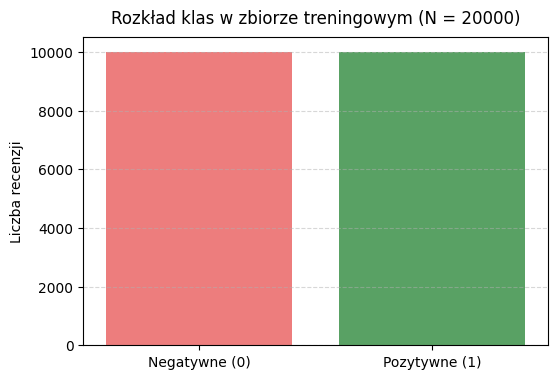

In [ ]:
plt.figure(figsize=(6, 4))
colors = ['#ff6b6b', '#4dad5b']
sns.barplot(x=['Negatywne (0)', 'Pozytywne (1)'], y=[train_counts[0], train_counts[1]], palette=colors)
plt.title(f'Rozkład klas w zbiorze treningowym (N = {len(train_data)})', fontsize=12, pad=10)
plt.ylabel('Liczba recenzji')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### **Analiza długości recenzji (Liczba słów)**

W przetwarzaniu tekstów przez sieci neuronowe (zwłaszcza rekurencyjne RNN/LSTM oraz modele oparte na atencji), kluczowym parametrem jest długość sekwencji wejściowej (`MAX_SEQ_LEN`).

* Zbyt niska wartość spowoduje bezpowrotne ucięcie tekstu (utratę kontekstu),
* Zbyt wysoka wartość drastycznie zwiększy koszt obliczeniowy i zapotrzebowanie na pamięć (w Transformerach złożoność obliczeniowa mechanizmu Self-Attention rośnie kwadratowo: $O(N^2)$ względem długości tekstu).

Poniższa analiza rozkładu liczby słów w recenzjach pozwoli nam podjąć świadomą i popartą danymi decyzję dotyczącą optymalnego przycięcia sekwencji wejściowych.

--- STATYSTYKI OPISOWE DŁUGOŚCI RECENZJI (LICZBA SŁÓW) ---
Średnia długość recenzji : 232.8 słów
Mediana długości         : 174.0 słów
Maksymalna długość       : 2470 słów
Minimalna długość        : 10 słów


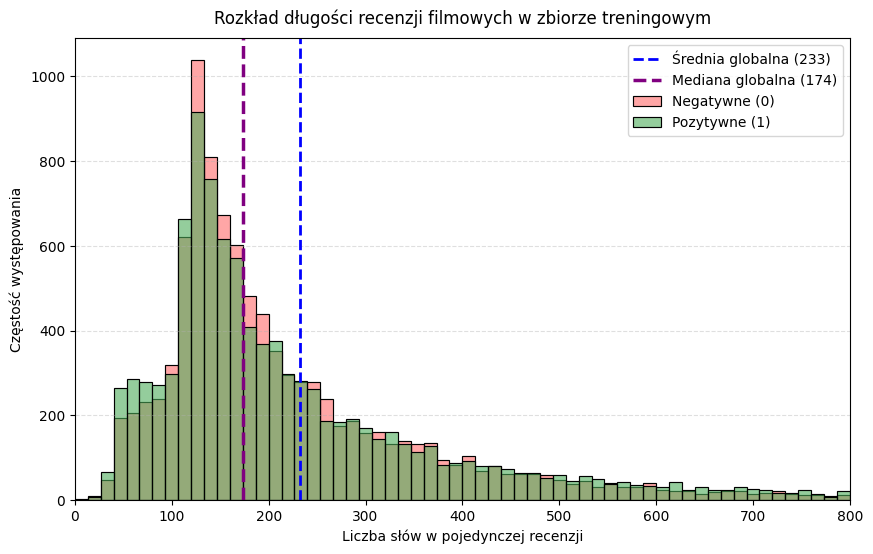

In [ ]:
# Obliczanie liczby słów dla każdego tekstu w zbiorze treningowym
train_lengths = [len(text.split()) for text in train_data['text']]
train_labels  = list(train_data['label'])

# Podział długości na dwie osobne listy
neg_lengths = [train_lengths[i] for i in range(len(train_lengths)) if train_labels[i] == 0]
pos_lengths = [train_lengths[i] for i in range(len(train_lengths)) if train_labels[i] == 1]

srednia_dlugosc = np.mean(train_lengths)
mediana_dlugosci = np.median(train_lengths)

print("--- STATYSTYKI OPISOWE DŁUGOŚCI RECENZJI (LICZBA SŁÓW) ---")
print(f"Średnia długość recenzji : {srednia_dlugosc:.1f} słów")
print(f"Mediana długości         : {mediana_dlugosci:.1f} słów")
print(f"Maksymalna długość       : {np.max(train_lengths)} słów")
print(f"Minimalna długość        : {np.min(train_lengths)} słów")

plt.figure(figsize=(10, 6))

sns.histplot(neg_lengths, color='#ff6b6b', label='Negatywne (0)', alpha=0.6, bins=60, binrange=(0, 800), kde=False)
sns.histplot(pos_lengths, color='#4dad5b', label='Pozytywne (1)', alpha=0.6, bins=60, binrange=(0, 800), kde=False)

plt.axvline(srednia_dlugosc, color='blue', linestyle='--', linewidth=2,
            label=f'Średnia globalna ({srednia_dlugosc:.0f})')
plt.axvline(mediana_dlugosci, color='purple', linestyle='--', linewidth=2.5,
            label=f'Mediana globalna ({mediana_dlugosci:.0f})')

plt.title('Rozkład długości recenzji filmowych w zbiorze treningowym', fontsize=12, pad=10)
plt.xlabel('Liczba słów w pojedynczej recenzji')
plt.ylabel('Częstość występowania')
plt.xlim(0, 800)

plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


* **Lokalne różnice w rozkładach:** Rozkłady klas nie są identyczne. Hstogram ujawnia, że wśród najkrótszych tekstów przeważają recenzje pozytywne, natomiast w przedziale około 150-200 słów (okolice mediany) widoczna jest lekka przewaga recenzji negatywnych.

* **Wybór MAX_SEQ_LEN = 200:** Przyjmujemy limit 200 słów, zorientowany na maksymalną wydajność obliczeniową. Wartość ta plasuje się powyżej mediany (174), co gwarantuje pełne zachowanie kontekstu dla większości recenzji, jednocześnie skutecznie odcinając ekstremalnie długie „ogony” tekstu.

* **Optymalizacja GPU:** Skrócenie sekwencji do 200 słów przyspieszy trening i drastycznie odciąży pamięć, co ma kluczowe znaczenie przy uczeniu Mini-Transformera oraz DistilBERT-a na dużym zbiorze 20 000 próbek.

### **Wizualizacja najczęstszych słów za pomocą Chmur Słów (WordClouds)**
Aby przyjrzeć się treści recenzji od strony semantycznej, generujemy dwie niezależne chmury słów - osobną dla sentymentu pozytywnego i negatywnego. Operacja ta pozwoli nam wzrokowo zweryfikować, czy w danych dominują słowa o oczekiwanym zabarwieniu emocjonalnym oraz czy w tekstach nie ma błędów technicznych. Przekonamy się również, czy same pojedyncze słowa wystarczą do oceny kontekstu.

Generowanie chmur słów dla 20 000 recenzji treningowych...


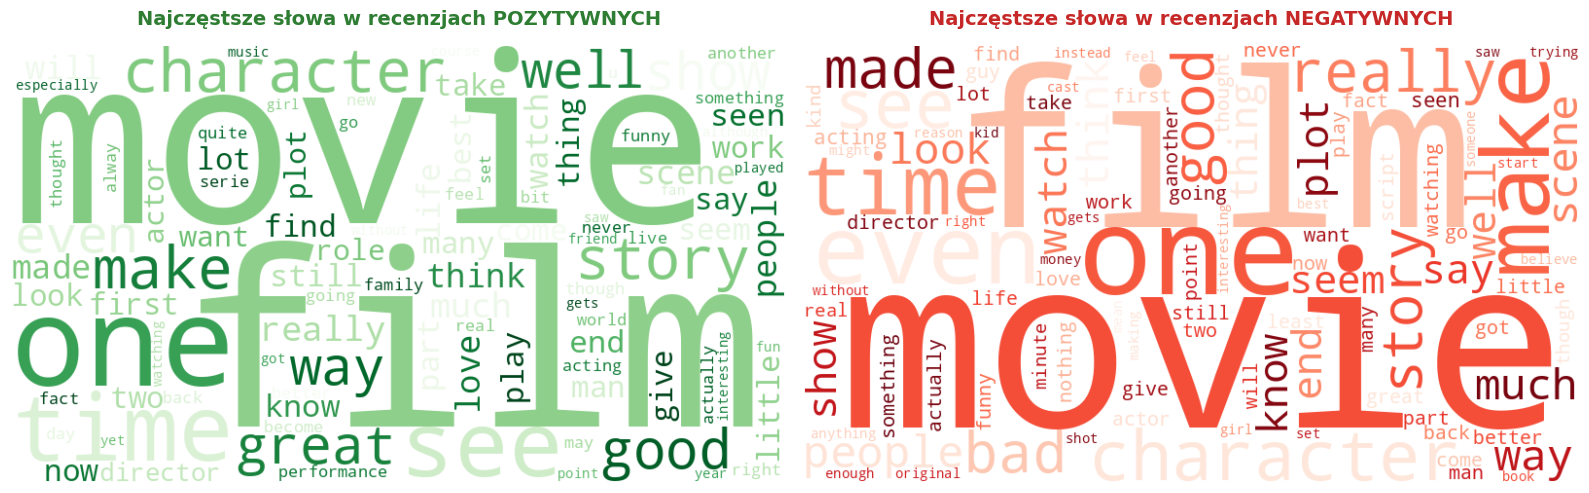

In [ ]:
print("Generowanie chmur słów dla 20 000 recenzji treningowych...")

# Wyciągamy teksty dla obu klas bezpośrednio ze zbioru treningowego
pozytywne_teksty = [text for text, label in zip(train_data['text'], train_data['label']) if label == 1]
negatywne_teksty = [text for text, label in zip(train_data['text'], train_data['label']) if label == 0]

# Łączymy listy recenzji w jeden wielki ciąg tekstowy dla każdej klasy
pelny_tekst_pos = " ".join(pozytywne_teksty)
pelny_tekst_neg = " ".join(negatywne_teksty)

# Oczyszczanie ze znaczników HTML <br />, aby nie zaburzały wyników wizualizacji
pelny_tekst_pos = re.sub(r'<br\s*/?>', ' ', pelny_tekst_pos)
pelny_tekst_neg = re.sub(r'<br\s*/?>', ' ', pelny_tekst_neg)

# Tworzenie chmur słów
wordcloud_pos = WordCloud(width=800, height=450, background_color='white', max_words=100, colormap='Greens').generate(pelny_tekst_pos)
wordcloud_neg = WordCloud(width=800, height=450, background_color='white', max_words=100, colormap='Reds').generate(pelny_tekst_neg)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title('Najczęstsze słowa w recenzjach POZYTYWNYCH', fontsize=14, pad=15, weight='bold', color='#2e7d32')
axes[0].axis('off')

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title('Najczęstsze słowa w recenzjach NEGATYWNYCH', fontsize=14, pad=15, weight='bold', color='#c62828')
axes[1].axis('off')

plt.tight_layout()
plt.show()

* **Wizualne podobieństwo i dominacja słów neutralnych:** Obie chmury słów są do siebie uderzająco podobne. W obu przypadkach największą przestrzeń zajmują dokładnie te same wyrazy neutralne, takie jak *movie, film, one, time, make*. Pokazuje to, że sam fakt pisania o filmie narzuca identyczne słownictwo bazowe dla obu klas.
* **Kontekst przymiotników:** Słowa o potencjalnym zabarwieniu emocjonalnym nakładają się na siebie - przykładowo słowo *good* jest bardzo widoczne zarówno w recenzjach pozytywnych, jak i negatywnych (gdzie występuje najczęściej w zaprzeczeniach, np. *"not good"*).
* **Uzasadnienie dla mechanizmu Attention:** Tak duże wymieszanie słowników sprawia, że proste metody zliczania wyrazów (Bag-of-Words) są bezużyteczne. Dopiero **mechanizm atencji w Transformerze** oraz pamięć sieci **LSTM** pozwolą modelom nadać przymiotnikom (*great, good, bad*) właściwe znaczenie, analizując ich bezpośrednie otoczenie i relacje z innymi słowami w zdaniu.

### **Podsumowanie EDA**

Przeprowadzona analiza eksploracyjna pozwoliła na wyciągnięcie kluczowych wniosków, które determinują dalsze kroki projektowe:

1. **Niejednorodność rozkładu długości:** Histogram z wyrównanymi koszykami wykazał lokalne różnice między klasami. Wśród najkrótszych recenzji dominują wypowiedzi pozytywne, natomiast w przedziale około 150-200 słów (okolice mediany) widoczna jest wyraźna recenzji negatywnych. Rozkład cechuje się skośnością prawostronną (mediana: 174, średnia: 233).
2. **Wysokie nakładanie się słowników (WordCloud):** Chmury słów udowodniły, że w obu klasach bezwzględnie dominują te same wyrazy strukturalne (*movie, film, time, make*). Ponieważ kluczowe przymiotniki emocjonalne (takie jak *good* czy *great*) występują w obu zbiorach (często w zaprzeczeniach lub ironii), proste metody zliczania słów byłyby nieskuteczne.
3. **Uzasadnienie architektury i wybór MAX_SEQ_LEN = 200:** Aby poprawnie sklasyfikować tak mocno wymieszany tekst, konieczne jest zastosowanie modeli badających kontekst i relacje między słowami (LSTM oraz mechanizm Atencji). Wybrany limit **200 słów** to idealny kompromis: pokrywa większość rozkładu tekstów, a zarazem drastycznie odciąża pamięć VRAM GPU. Ma to krytyczne znaczenie dla Mini-Transformera i DistilBERT-a, w których koszt obliczeniowy atencji rośnie kwadratowo ($O(N^2)$) względem długości sekwencji.

## 5. Tworzenie słownika i tokenizacja

W tym rozdziale przygotowujemy surowy tekst recenzji do formatu akceptowanego przez sieci neuronowe. Proces ten realizujemy w sposób dynamiczny, bezpośrednio podczas ładowania paczek danych, co optymalizuje zużycie pamięci.

Proces składa się z następujących etapów:
1. **Czyszczenie tekstu:** Usunięcie znaczników HTML (`<br />`), odrzucenie znaków niebędących literami oraz ujednolicenie wielkości liter.
2. **Budowa słownika (Vocab):** Wyciągnięcie unikalnych tokenów **wyłącznie ze zbioru treningowego** (ochrona przed *data leakage*), z ograniczeniem do `MAX_VOCAB_SIZE` oraz rezerwacją indeksów dla tokenów specjalnych: `<PAD>` (uzupełnianie braków) i `<UNK>` (nieznane słowa).
3. **Dynamiczny Padding i Truncation:** Wyrównanie każdej recenzji do wyznaczonego w sekcji EDA limitu `MAX_SEQ_LEN = 200`.

In [ ]:
# 1. PARAMETRY
MAX_SEQ_LEN = 200
MAX_VOCAB_SIZE = 20000 # Maksymalny rozmiar słownika
BATCH_SIZE = 64

# 2. FUNKCJA CZYSZCZĄCA I TOKENIZUJĄCA
def clean_and_tokenize(text):
    text = re.sub(r'<br\s*/?>', ' ', text) # Usuwanie tagów HTML
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Usuwanie znaków specjalnych i cyfr
    return text.lower().split()

print("Krok 1: Budowanie słownika na podstawie zbioru treningowego...")

# 3. BUDOWA SŁOWNIKA
all_tokens = []
for item in train_data:
    all_tokens.extend(clean_and_tokenize(item['text']))

counter = Counter(all_tokens)
vocab = {'<PAD>': 0, '<UNK>': 1} # Rezerwacja indeksów specjalnych

# Mapowanie najczęstszych słów na kolejne indeksy
for word, _ in counter.most_common(MAX_VOCAB_SIZE):
    vocab[word] = len(vocab)

print(f"-> Sukces! Utworzono słownik o rozmiarze: {len(vocab)} tokenów.")

# 4. FUNKCJA DYNAMICZNEGO PAKOWANIA I WYRÓWNYWANIA (Collate Function)
def collate_fn(batch):
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    texts = []

    for item in batch:
        tokens = clean_and_tokenize(item['text'])
        # Zamiana słów na indeksy (brak słowa w słowniku = 1, czyli <UNK>)
        indices = [vocab.get(token, 1) for token in tokens[:MAX_SEQ_LEN]]

        # Padding z prawej strony (uzupełnianie zerami)
        if len(indices) < MAX_SEQ_LEN:
            indices += [0] * (MAX_SEQ_LEN - len(indices))

        texts.append(indices)

    return torch.tensor(texts, dtype=torch.long), labels

print("\nKrok 2: Inicjalizacja PyTorch DataLoderów...")

# 5. TWORZENIE DATALOADERÓW
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, collate_fn=collate_fn)

print("-> DataLoadery są gotowe do pracy!")

Krok 1: Budowanie słownika na podstawie zbioru treningowego...
-> Sukces! Utworzono słownik o rozmiarze: 20002 tokenów.

Krok 2: Inicjalizacja PyTorch DataLoderów...
-> DataLoadery są gotowe do pracy!


### **Weryfikacja formatu DataLoaderów**

In [ ]:
# Pobieramy jedną przykładową paczkę z train_loader
for X_batch, y_batch in train_loader:
    print("--- WERYFIKACJA FORMATU DATALOADERA ---")
    print(f"Kształt macierzy tekstów (X_batch) : {X_batch.shape}")
    print(f"Kształt wektora etykiet (y_batch)  : {y_batch.shape}")
    print(f"Typ danych w macierzy              : {X_batch.dtype}")
    print(f"Pierwsze 10 tokenów pierwszej recenzji z paczki:\n{X_batch[0][:10]}")
    break

--- WERYFIKACJA FORMATU DATALOADERA ---
Kształt macierzy tekstów (X_batch) : torch.Size([64, 200])
Kształt wektora etykiet (y_batch)  : torch.Size([64])
Typ danych w macierzy              : torch.int64
Pierwsze 10 tokenów pierwszej recenzji z paczki:
tensor([1830,    4, 1201, 1474,   15,  143,    5,   22,   12,  736])


Powyższy wynik potwierdza, że potok dynamicznego przetwarzania danych działa **poprawnie**:

* **`torch.Size([64, 200])`**: `DataLoader` prawidłowo dzieli dane na paczki. Każdy batch zawiera dokładnie **64 recenzje**, a każda z nich została równo docięta lub dopełniona zerami (padding) do wybranego limitu **200 słów**.
* **`torch.Size([64])`**: Paczka zawiera dokładnie 64 odpowiadające recenzjom etykiety klasowe (0 dla negatywnych, 1 dla pozytywnych).
* **`tensor([1830,    4, 1201, ...])`**: Tekst został pomyślnie zamieniony na unikalne indeksy liczbowe typu całkowitego (`torch.int64`).

Dane strukturalne są w pełni gotowe, aby w następnym kroku zasilić pierwszą warstwę (`nn.Embedding`) naszych autorskich modeli sieciowych.

### **Tokenizacja dla modelu DistilBERT**

Model DistilBERT wymaga specyficznego formatowania danych wejściowych, zgodnego z jego architekturą. W tym celu wykorzystujemy tokenizator `DistilBertTokenizerFast`.

Tokenizator ten automatycznie:
1. Mapuje słowa na tokeny z oficjalnego, pre-definiowanego słownika modelu.
2. Dodaje tokeny strukturalne: `[CLS]` (reprezentujący kontekst całej sekwencji) oraz `[SEP]` (oznaczający koniec tekstu).
3. Tworzy tzw. **Attention Mask** (maskę uwagi) - wektor binarny informujący model, które elementy sekwencji to rzeczywiste słowa (wartość 1), a które to dopełnienie `<PAD>` (wartość 0).

In [ ]:
print("Ładowanie pre-trenowanego tokenizera dla DistilBERT-a...")

tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Wyciągamy surowe teksty i etykiety dla wszystkich zbiorów
train_texts, y_train_bert = [item['text'] for item in train_data], [item['label'] for item in train_data]
val_texts, y_val_bert     = [item['text'] for item in val_data], [item['label'] for item in val_data]
test_texts, y_test_bert   = [item['text'] for item in test_data], [item['label'] for item in test_data]

print("\nTokenizacja zbiorów...")

# Tokenizujemy całe zbiory na raz. Wykorzystujemy wyznaczony limit MAX_SEQ_LEN = 200.
# Oczyszczanie z <br /> robimy w locie za pomocą prostej zamiany w liście skróconej.
train_encodings = tokenizer_bert([t.replace('<br />', ' ') for t in train_texts], truncation=True, padding=True, max_length=MAX_SEQ_LEN)
val_encodings   = tokenizer_bert([t.replace('<br />', ' ') for t in val_texts], truncation=True, padding=True, max_length=MAX_SEQ_LEN)
test_encodings  = tokenizer_bert([t.replace('<br />', ' ') for t in test_texts], truncation=True, padding=True, max_length=MAX_SEQ_LEN)

# Klasa pomocnicza zamieniająca słowniki tokenizera na standardowy PyTorch Dataset
class IMDbBertDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Wyciągamy input_ids oraz attention_mask dla danego indeksu
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Tworzenie obiektów Dataset
train_bert_dataset = IMDbBertDataset(train_encodings, y_train_bert)
val_bert_dataset   = IMDbBertDataset(val_encodings, y_val_bert)
test_bert_dataset  = IMDbBertDataset(test_encodings, y_test_bert)

# Inicjalizacja DataLoaderów dla BERT-a
# Używamy mniejszego batch_size=16, aby chronić pamięć GPU przed przepełnieniem
train_loader_bert = DataLoader(train_bert_dataset, batch_size=16, shuffle=True)
val_loader_bert   = DataLoader(val_bert_dataset, batch_size=16)
test_loader_bert  = DataLoader(test_bert_dataset, batch_size=16)

print("-> Sukces! DataLoadery dla DistilBERT-a zostały utworzone.")

Ładowanie pre-trenowanego tokenizera dla DistilBERT-a...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Tokenizacja zbiorów...
-> Sukces! DataLoadery dla DistilBERT-a zostały utworzone.


## 6. Budowa funkcji

W procesie treningu wykorzystaliśmy funkcje, będące bezpośrednim rozwinięciem rozwiązań z naszych **poprzednich projektów**:

- **`train_model`**: Zautomatyzowana pętla ucząca z monitoringiem wyników na zbiorze walidacyjnym w każdej epoce.
- **`plot_training_history`**: Generowanie wykresów strat (Loss) i dokładności (Accuracy), pozwalających na szybką ocenę overfittingu.
- **`compare_models`**: Kluczowe narzędzie pozwalające zestawić wyniki różnych modeli na jednym wykresie. Umożliwia bezpośrednie porównanie wydajności naszej architektury z modelami pretrenowanymi.

Dodaliśmy także nową, kluczową funkcję ewaluacyjną:

* **`evaluate_and_plot_cm`**: Narzędzie dedykowane do ostatecznej weryfikacji modeli na całkowicie odseparowanym zbiorze testowym. Rozszerza ono standardową metrykę dokładności (Accuracy) o pełną analizę **macierzy błędów (Confusion Matrix)** wizualizowaną w formie mapy ciepła (*heatmap*).

### **Funkcja TRENINGU**

In [ ]:
def train_model(model, name, train_loader, val_loader, opt_type='adam', epochs=100, lr=0.001, wd=0.0, class_weights=None):
    # Używamy globalnego DEVICE zadeklarowanego wcześniej
    global DEVICE

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    else:
        criterion = nn.CrossEntropyLoss()

    if opt_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}
    best_v_loss = float('inf')
    patience = 5
    counter = 0

    print(f'\n>>> Rozpoczęto trening modelu: {name}')

    for epoch in range(epochs):
        # --- FAZA TRENINGU ---
        model.train()
        t_loss = 0.0
        t_correct = 0

        # Pasek postępu dla fazy treningowej (leave=False czyści pasek po skończeniu epoki)
        train_bar = tqdm(train_loader, desc=f'Epoka {epoch+1:2d}/{epochs} [TRENING]', leave=False)

        for inputs, targets in train_bar:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad()

            # Obsługa tupli zwracanej przez Transformera
            out = model(inputs)
            out = out[0] if isinstance(out, tuple) else out

            loss = criterion(out, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            t_loss += loss.item()
            t_correct += (out.argmax(1) == targets).sum().item()

            # Wyświetlanie aktualnego kosztu loss w locie na pasku
            train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        # --- FAZA WALIDACJI ---
        model.eval()
        v_loss, correct = 0.0, 0

        # Pasek postępu dla fazy walidacyjnej
        val_bar = tqdm(val_loader, desc=f'Epoka {epoch+1:2d}/{epochs} [WALIDACJA]', leave=False)

        with torch.no_grad():
            for inputs, targets in val_bar:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                out = model(inputs)
                out = out[0] if isinstance(out, tuple) else out

                v_loss += criterion(out, targets).item()
                correct += (out.argmax(1) == targets).sum().item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        avg_t_acc = t_correct / len(train_loader.dataset) * 100
        acc = correct / len(val_loader.dataset) * 100

        scheduler.step(avg_v)

        history['t_loss'].append(avg_t)
        history['v_loss'].append(avg_v)
        history['t_acc'].append(avg_t_acc)
        history['v_acc'].append(acc)

        if (epoch + 1) % 1 == 0:
            print(f'Epoka {epoch+1:2d} | Train Loss: {avg_t:.4f} | Val Loss: {avg_v:.4f} | Val Acc: {acc:.2f}%')

        # Logika Early Stopping i zapisu wag
        if avg_v < best_v_loss:
            best_v_loss = avg_v
            counter = 0
            torch.save(model.state_dict(), f'best_model_{name.replace(" ", "_")}.pth')
        else:
            counter += 1
            if counter >= patience:
                print(f'--- Early Stopping w epoce {epoch+1} ---')
                break

    # Wczytanie najlepszych wag po treningu
    print(f"Przywracanie najlepszych wag dla modelu: {name}...")
    model.load_state_dict(torch.load(f'best_model_{name.replace(" ", "_")}.pth'))

    return history

### **Funkcja WYKRESU**

In [ ]:
def plot_training_results(history, name):
    epochs = range(1, len(history['t_loss']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['t_loss'], 'b-', label='Strata treningu')
    plt.plot(epochs, history['v_loss'], 'r-', label='Strata walidacji')
    plt.title(f'Funkcja straty - {name}')
    plt.xlabel('Epoki')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['t_acc'], 'y-', label='Dokładność treningu')
    plt.plot(epochs, history['v_acc'], 'g-', label='Dokładność walidacji')
    plt.title(f'Dokładność (Accuracy) - {name}')
    plt.xlabel('Epoki')
    plt.ylabel('Acc (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### **Funkcja PORÓWNAWCZA**


In [ ]:
def compare_models(histories, names):
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    for hist, name in zip(histories, names):
        plt.plot(hist['v_loss'], label=f'{name} (Loss)')
    plt.title('Porównanie błędu walidacji (Val Loss)')
    plt.xlabel('Epoki')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for hist, name in zip(histories, names):
        plt.plot(hist['v_acc'], label=f'{name} (Acc)')
    plt.title('Porównanie dokładności walidacji (Val Acc)')
    plt.xlabel('Epoki')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### **Funkcja EWALUACJA + CONFUSION MATRIX**

In [ ]:
def evaluate_and_plot_cm(model, loader, model_name):
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            # Obsługa formatu dla DistilBERT
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                labels = batch['labels'].to(DEVICE)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            # Obsługa formatu dla LSTM / Mini-Transformera
            else:
                texts, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
                outputs = model(texts)

            if hasattr(outputs, 'logits'):
                predictions = outputs.logits  # Dla BERT-a
            else:
                predictions = outputs[0] if isinstance(outputs, tuple) else outputs  # Dla LSTM/Transformera

            _, predicted = torch.max(predictions, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total * 100

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatywna', 'Pozytywna'], yticklabels=['Negatywna', 'Pozytywna'])
    plt.title(f'Macierz Błędów (Confusion Matrix) - {model_name}')
    plt.ylabel('Prawdziwa Etykieta')
    plt.xlabel('Predykcja Modelu')
    plt.show()

    print(f'\n>>> Ostateczna skuteczność (Accuracy) dla {model_name} na zbiorze testowym: {accuracy:.2f}%\n')

## 7. Eksperyment 1: Vanilla RNN (Klasyczna Sieć Rekurencyjna)

**Założenia Teoretyczne:**
Standardowa sieć rekurencyjna (Vanilla RNN) przetwarza tekst w sposób sekwencyjny - słowo po słowie, aktualizując w każdym kroku czasowym swój wewnętrzny stan ukryty (*hidden state*). Architektura ta posiada dwie krytyczne wady matematyczne, które ten eksperyment ma intencjonalnie obnażyć:

1. **Zjawisko zanikającego gradientu (Vanishing Gradient Problem):** Podczas propagacji wstecznej przez czas (*Backpropagation Through Time*), błąd jest przekazywany wstecz przez setki kroków rekurencji. Operacja ta opiera się na wielokrotnym mnożeniu macierzy wag. Jeśli wartości tych wag są małe, gradienty maleją wykładniczo, dążąc do zera. W efekcie, docierając do limitu `MAX_SEQ_LEN = 200`, sieć modyfikuje swoje parametry wyłącznie na podstawie ostatnich kilku słów, kompletnie zapominając kontekst z początku recenzji.
2. **Efekt rozmywania pamięci przez padding (<PAD>):** W przypadku recenzji krótszych niż 200 słów, pozostała część sekwencji jest dynamicznie uzupełniana tokenami specyficznymi `<PAD>` (o wartościach indeksu 0). Ponieważ klasyczna sieć RNN nie posiada mechanizmów selektywnego zapamiętywania (bramkowania), przetwarzanie kilkudziesięciu lub kilkunastu pustych tokenów na końcu sekwencji bezlitośnie "nadpisuje" i rozmywa wyuczony wcześniej wektor kontekstu. Do warstwy liniowej trafia stan ukryty zniekształcony przez puste sygnały wejściowe.

**Cel eksperymentu:**
Niniejsze badanie ma na celu empiryczne wykazanie niestabilności i ograniczeń bazowej architektury rekurencyjnej, stanowiąc niski punkt odniesienia (*baseline*) dla bardziej zaawansowanych struktur (LSTM, Transformer).

In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(emb_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, 2)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        # Wyciągamy ostatni stan ukryty (hidden state), który teoretycznie ma zawierać
        # kontekst całego zdania i przepuszczamy przez warstwę liniową
        return self.fc(hidden.squeeze(0))



### **Proces uczenia sieci Vanilla RNN**

In [ ]:
model_rnn = VanillaRNN(len(vocab)).to(DEVICE)
history_rnn = train_model(model_rnn, 'Vanilla RNN', train_loader, val_loader, opt_type='adam', epochs=10, lr=0.001)


>>> Rozpoczęto trening modelu: Vanilla RNN


Epoka  1/10 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoka  1/10 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  1 | Train Loss: 0.6994 | Val Loss: 0.6925 | Val Acc: 51.76%


Epoka  2/10 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoka  5/10 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  5 | Train Loss: 0.6486 | Val Loss: 0.7309 | Val Acc: 53.20%


Epoka  6/10 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoka  6/10 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  6 | Train Loss: 0.6103 | Val Loss: 0.7546 | Val Acc: 56.36%
--- Early Stopping w epoce 6 ---
Przywracanie najlepszych wag dla modelu: Vanilla RNN...


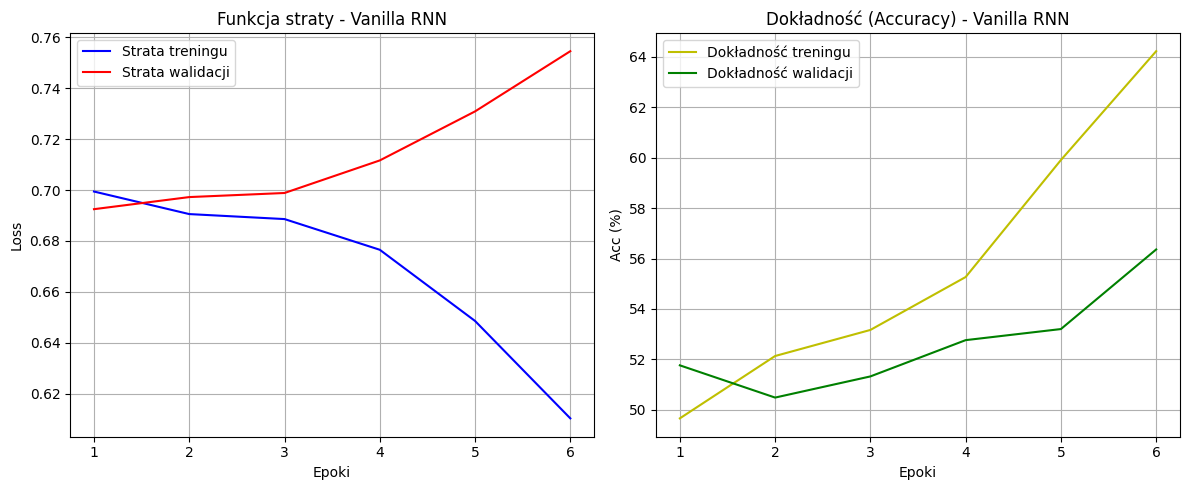

In [ ]:
plot_training_results(history_rnn, 'Vanilla RNN')

### **Analiza treningu sieci Vanilla RNN**

Analiza wykresów historii uczenia oraz ostatecznych metryk walidacyjnych dostarcza bezpośrednich dowodów na teoretyczne ograniczenia klasycznej sieci rekurencyjnej:

* **Rozbieżność funkcji straty:** Podczas gdy strata treningowa (*Train Loss*) systematycznie spadała z poziomu `0.6994` do `0.6103`, strata walidacyjna (*Val Loss*) wykazywała gwałtowny trend wzrostowy, kończąc proces na poziomie `0.7546`. Świadczy to o natychmiastowym odklejeniu się modelu od realnej struktury języka i silnym przeuczeniu.
* **Stagnacja dokładności (Accuracy):** Dokładność walidacyjna (*Val Acc*) oscylowała chaotycznie w przedziale **50.48% – 56.36%**. Przy idealnie zbalansowanym zbiorze danych (rozkład klas 50/50) wynik ten jest niemal równoważny z losowym zgadywaniem (rzutem monetą).
* **Działanie Early Stopping:** Ze względu na stale rosnący błąd walidacji, pętla uczenia przerwała proces w 6. epoce. Mechanizm automatycznego zapisu przywrócił optymalne wagi modelu z **1. epoki**, gdzie wskaźnik *Val Loss* osiągnął swoje globalne minimum (`0.6925`) przy dokładności walidacyjnej wynoszącej `51.76%`.

> **Podsumowanie eksperymentu:**
> Klasyczna architektura RNN okazała się bezradna w zadaniu analizy sentymentu przy długości sekwencji `MAX_SEQ_LEN = 200`. Eksperyment potwierdził występowanie zjawiska **zanikającego gradientu** (sieć traci kontekst z początku recenzji) oraz **rozmywania pamięci** stanu ukrytego przez seryjnie przetwarzane na końcu tekstu tokeny dopełnienia (`<PAD>`). Wynik ten stanowi doskonały, niski punkt odniesienia (*baseline*) dla kolejnych etapów badania.

### **Ewaluacja na zbiorze testowym i analiza macierzy błędów (Vanilla RNN)**

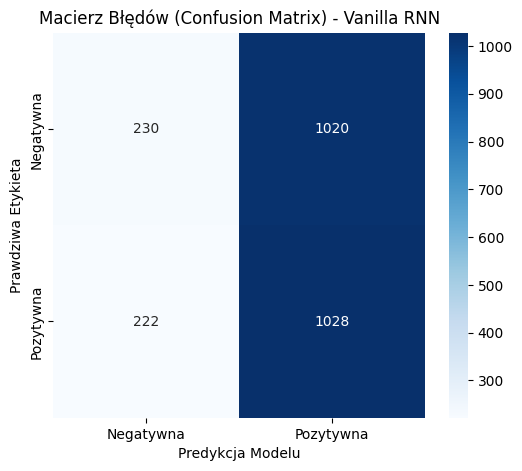


>>> Ostateczna skuteczność (Accuracy) dla Vanilla RNN na zbiorze testowym: 50.32%



In [ ]:
evaluate_and_plot_cm(model_rnn, test_loader, 'Vanilla RNN')

Ostateczna weryfikacja zdolności generalizacyjnych modelu Vanilla RNN na odseparowanym zbiorze testowym przyniosła wynik skuteczności (*Accuracy*) na poziomie **50.32%**.

Szczegółowa analiza wygenerowanej macierzy błędów (*Confusion Matrix*) pozwala na sformułowanie następujących wniosków:

* **Potwierdzenie losowości działania:** Wynik na poziomie 50.32% przy idealnie zbalansowanym zbiorze (klasy 50/50) oznacza, że sieć całkowicie utraciła realne zdolności klasyfikacyjne. Główna przekątna zawiera jedynie **230** True Negatives oraz **1028** True Positives.
* **Silne skrzywienie (Bias) modelu:** Macierz ujawnia całkowitą degenerację procesu decyzyjnego. Sieć niemal bezwarunkowo faworyzowała klasę pozytywną, przypisując ją aż do 2048 recenzji (generując przy tym aż **1020** błędów typu False Positive). Oznacza to, że model przestał analizować tekst, a zaczął masowo "zgadywać" jedną, dominującą według niego klasę.
* **Weryfikacja założeń:** Tak fatalny rozkład predykcji jednoznacznie potwierdza teorię. Przez zjawisko zanikającego gradientu oraz negatywny wpływ długich sekwencji tokenów dopełnienia (`<PAD>`), sieć Vanilla RNN całkowicie zignorowała strukturę semantyczną tekstu i nie potrafiła powiązać słów kluczowych z kontekstem opinii.

> **Podsumowanie sekcji testowej:**
> Wynik 50.32% ostatecznie udowadnia, że klasyczna sieć RNN nie nadaje się do przetwarzania długich sekwencji tekstowych. Stanowi ona jednak doskonały punkt odniesienia (*baseline*), pokazujący jak głębokie i konieczne były zmiany architektoniczne wprowadzone w modelach LSTM oraz Transformer.

## 8. Eksperyment 2: Dwukierunkowa sieć LSTM (Bidirectional Long Short-Term Memory)

**Założenia Teoretyczne:**
Bezpośrednią odpowiedzią na problemy matematyczne klasycznej sieci RNN (zanikanie gradientu oraz rozmywanie pamięci przez tokeny dopełnienia) jest architektura LSTM. Wprowadza ona dedykowany mechanizm wewnętrznej pamięci, oparty na tzw. **stanie komórkowym** (*cell state*) oraz zespole trzech bramek nieliniowych, które sterują przepływem informacji w czasie:
1. **Bramka zapominania** (*forget gate*): Decyduje, które informacje z poprzednich kroków czasowych są nieistotne i należy je usunąć ze stanu komórkowego.
2. **Bramka wejściowa** (*input gate*): Kontroluje, jakie nowe informacje z bieżącego tokenu warto zapisać w pamięci.
3. **Bramka wyjściowa** (*output gate*): Określa, jaka część stanu komórkowego zostanie przekazana jako jawny stan ukryty do następnego kroku.

Dzięki tej strukturze gradient podczas propagacji wstecznej może przejść przez stan komórkowy bez przeszkód (brak operacji ciągłego mnożenia przez te same wagi), co pozwala modelowi utrzymać długoterminowe zależności przy długości sekwencji `MAX_SEQ_LEN = 200`.

### Zastosowanie dwukierunkowości (Bidirectional LSTM) i głębokości
W celu maksymalizacji zdolności ekstrakcji cech semantycznych, w eksperymencie wdrożono architekturę **dwukierunkową** złożoną z **dwóch warstw rekurencyjnych**:
* **Dwukierunkowość:** Tekst analizowany jest równolegle od lewej do prawej (w celu wychwycenia kontekstu historycznego) oraz od prawej do lewej (kontekst przyszły). W analizie sentymentu jest to kluczowe - model przed podjęciem decyzji o wadze słowa (np. *"dobry"*) wie, czy wcześniej lub później nie wystąpiło zaprzeczenie (np. *"wcale nie"*).
* **Głębokość i regularyzacja:** Zastosowanie dwóch warstw pozwala na budowanie hierarchicznej reprezentacji tekstu. Aby zapobiec zjawisku przeuczenia (*overfitting*) tak złożonej struktury, pomiędzy warstwami oraz przed ostatecznym klasyfikatorem liniowym zaimplementowano warstwę stochastycznego odrzucania neuronów (**Dropout = 0.5**).

**Cel eksperymentu:**
Empiryczne zweryfikowanie skuteczności mechanizmu bramkowania i dwukierunkowej analizy tekstu. Oczekuje się drastycznego wzrostu dokładności klasyfikacji na zbiorze testowym w porównaniu do bazowego modelu Vanilla RNN.

In [ ]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hid_dim=128, n_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                            batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        # Mnożymy x2 ze względu na dwukierunkowość
        self.fc = nn.Linear(hid_dim * 2, 2)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        # Łączymy stany z warstwy czytającej do przodu i do tyłu
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))



### **Proces uczenia sieci LSTM**

In [ ]:
model_lstm = SentimentLSTM(len(vocab)).to(DEVICE)

history_lstm = train_model(
    model_lstm,
    'Bidirectional LSTM',
    train_loader,
    val_loader,
    opt_type='adam',
    epochs=30,
    lr=0.001
)


>>> Rozpoczęto trening modelu: Bidirectional LSTM


Epoka  1/30 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoka  1/30 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  1 | Train Loss: 0.6774 | Val Loss: 0.6662 | Val Acc: 61.16%


Epoka  2/30 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoka 10/30 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka 10 | Train Loss: 0.2937 | Val Loss: 0.4507 | Val Acc: 84.12%


Epoka 11/30 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoka 11/30 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka 11 | Train Loss: 0.2694 | Val Loss: 0.5024 | Val Acc: 84.68%
--- Early Stopping w epoce 11 ---
Przywracanie najlepszych wag dla modelu: Bidirectional LSTM...


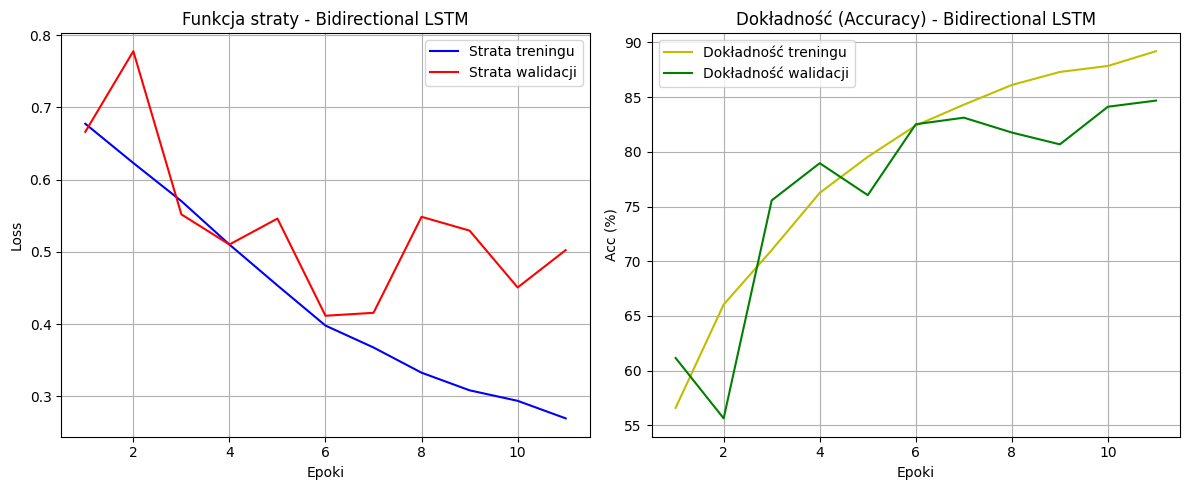

In [ ]:
plot_training_results(history_lstm, 'Bidirectional LSTM')

### **Analiza treningu sieci Bidirectional LSTM**

Wdrożenie mechanizmu bramkowania oraz dwukierunkowości (Bidirectional) przyniosło radykalną poprawę jakości procesu uczenia w stosunku do bazowego eksperymentu z klasyczną siecią RNN:

* **Zbieżność treningowa:** Strata treningowa (*Train Loss*) konsekwentnie i stabilnie malała z poziomu `0.6774` aż do `0.2694` w ostatniej epoce. Dokładność na zbiorze treningowym płynnie wzrosła z wyjściowych `56.5%` do blisko `89.2%`, co potwierdza wysoką zdolność sieci do ekstrakcji i mapowania cech semantycznych tekstu.
* **Niestabilność początkowa i Overfitting:** Wykresy ujawniają gwałtowne załamanie parametrów w 2. epoce, gdzie błąd walidacji drastycznie skoczył do `0.7778`, a dokładność spadła do `55.64%`. Model zdołał jednak przezwyciężyć to lokalne minimum. Po osiągnięciu optymalnego punktu w 6. epoce, funkcja straty walidacyjnej zaczęła ponownie powoli rosnąć, co wskazuje na powstawanie zjawiska przeuczenia (*overfitting*).
* **Działanie Early Stopping:** Ze względu na brak trwałej poprawy błędu walidacyjnego przez kolejne 5 epok (zgodnie z parametrem *patience*), proces uczenia został automatycznie przerwany w **11. epoce**. Mechanizm automatycznego zapisu prawidłowo przywrócił najlepsze wagi modelu z **6. epoki**, w której wskaźnik *Val Loss* osiągnął swoje globalne minimum (`0.4115`) przy bardzo wysokiej dokładności walidacyjnej wynoszącej **82.52%**.

> **Podsumowanie eksperymentu:**
> Zastosowanie dwukierunkowej sieci LSTM pozwoliło na spektakularny skok efektywności w porównaniu do Vanilla RNN. Wynik ten bezdyskusyjnie potwierdza, że komórki pamięciowe oraz bramki (zapominania, wejściowa i wyjściowa) skutecznie eliminują problem zanikającego gradientu. Dodatkowo, analiza tekstu od początku do końca oraz od końca do początku jednocześnie (dwukierunkowość) pozwoliła modelowi na stabilne i długodystansowe operowanie pełnym kontekstem recenzji.

### **Ewaluacja na zbiorze testowym i analiza macierzy błędów (LSTM)**

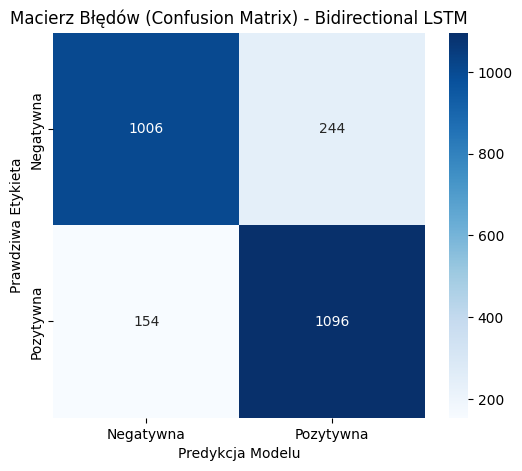


>>> Ostateczna skuteczność (Accuracy) dla Bidirectional LSTM na zbiorze testowym: 84.08%



In [ ]:
evaluate_and_plot_cm(model_lstm, test_loader, 'Bidirectional LSTM')

Ostateczny test modelu Bidirectional LSTM na odseparowanych danych testowych przyniósł wysoki wynik skuteczności (*Accuracy*) na poziomie **84.08%**.

Analiza uzyskanej macierzy błędów (*Confusion Matrix*) pozwala na wyciągnięcie następujących wniosków:

* **Wysoka zdolność predykcyjna:** Model poprawnie sklasyfikował aż 2102 z 2500 recenzji testowych. Główna przekątna macierzy jest wyraźnie zdominowana przez poprawne wyniki: **1006** przypadków True Negatives (prawdziwie negatywne) oraz **1096** True Positives (prawdziwie pozytywne).
* **Asymetria błędów (Tendencja optymistyczna):** Sieć rzadziej popełniała błąd typu *False Negative* (154 przypadki – błędne uznanie recenzji pozytywnej za negatywną) niż błąd typu *False Positive* (244 przypadki – błędne uznanie recenzji negatywnej za pozytywną). Oznacza to, że model wykazuje lekką skłonność do "optymistycznej" interpretacji tekstu, wykazując większą swobodę w przypisywaniu klasy pozytywnej w sytuacjach niejednoznacznych.
* **Doskonała generalizacja:** Wynik testowy (**84.08%**) niemal idealnie pokrywa się z najwyższą wartością uzyskaną podczas walidacji (**84.12%**). Dowodzi to, że wdrożona warstwa *Dropout (0.5)* oraz mechanizm regularyzacji skutecznie zabezpieczyły sieć przed przeuczeniem. Model realnie przyswoił uniwersalne wzorce językowe, zamiast zapamiętać zbiór treningowy na pamięć.

> **Podsumowanie sekcji testowej:**
> Wynik 84.08% ostatecznie potwierdza druzgocącą przewagę architektury dwukierunkowego LSTM nad klasycznym RNN (50.32%). Model udowodnił wysoką zdolność do radzenia sobie z długimi sekwencjami tekstowymi, a uzyskana macierz błędów cechuje się stabilnym zbalansowaniem predykcji.

## 9. Eksperyment 3: Autorski Mini-Transformer (Mechanizm Atencji)

**Założenia Teoretyczne:**
Trzeci eksperyment stanowi całkowite odejście od sieci rekurencyjnych na rzecz architektury opartej wyłącznie o mechanizm samoatencji (*Self-Attention*). W przeciwieństwie do modeli RNN/LSTM, które przetwarzają tekst sekwencyjnie (słowo po słowie), Transformer przetwarza całą sekwencję tekstową w sposób w pełni równoległy. Pozwala to na skrócenie czasu obliczeń oraz eliminuje problem zanikania gradientu w czasie.

### 1. Matematyka mechanizmu Scaled Dot-Product Attention
Sercem modelu jest przekształcenie wejściowych reprezentacji słów w trzy niezależne przestrzenie wektorowe za pomocą wyuczalnych macierzy wag: **Query ($Q$ — zapytanie)**, **Key ($K$ — klucz)** oraz **Value ($V$ — wartość)**. Relacje semantyczne pomiędzy słowami w zdaniu są obliczane zgodnie z oficjalnym wzorem matematycznym architektury Transformer:

$$\text{Attention}(Q, K, V) = \text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Gdzie $d_k$ oznacza wymiarowość kluczy (skalowanie zapobiega zbyt małym wartościom gradientu funkcji Softmax). Wynikiem tej operacji jest macierz wag atencji, która dynamicznie decyduje, na których fragmentach recenzji model powinien się "skupić" podczas oceny sentymentu.

### 2. Wielogłowicowość (Multi-Head Attention = 8)
W celu optymalizacji zdolności ekstrakcji cech semantycznych, w modelu zaimplementowano architekturę **8-głowicową** (`num_heads = 8`). Wymiar osadzenia słów `emb_dim = 128` jest matematycznie dzielony na 8 niezależnych podprzestrzeni o wymiarze $16$ każda ($128 / 8 = 16$).
Każda z 8 głowic uczy się analizować tekst pod innym kątem (np. jedna głowica mapuje relacje rzeczownik-przymiotnik, inna wychwytuje operatory negacji, a jeszcze inna analizuje interpunkcję). Ostateczne wektory z każdej głowicy są na końcu konsolidowane (konkatenowane) z powrotem do wymiaru 128.

### 3. Kodowanie pozycyjne (Positional Embedding)
Ponieważ operacje w Transformerze zachodzą równolegle, sieć domyślnie traci informację o kolejności słów (traktuje zdanie jak zwykły zbiór słów). Aby zachować strukturę składniową tekstu, wdrożono trenowalną warstwę `self.position_embedding` mapowaną na limit 200 słów. Wektor pozycji jest dodawany bezpośrednio do wektora znaczenia słowa przed przekazaniem danych do modułu atencji.

### 4. Agregacja kontekstu (Global Average Pooling)
Wyjściem z warstwy normalizacji (`LayerNorm`) jest tensor o kształcie `[BATCH_SIZE, 200, 128]`, reprezentujący 200 słów nasyconych globalnym kontekstem całego zdania. Ponieważ zadaniem sieci jest klasyfikacja binarna *całej recenzji* (sentyment pozytywny lub negatywny), wymiar sekwencji jest redukowany za pomocą operacji uśredniania:
```python
out_pooled = out.mean(dim=1)

In [ ]:
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, num_heads=8, max_seq_len=200):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        # Osadzanie pozycyjne
        self.position_embedding = nn.Embedding(max_seq_len, emb_dim)

        # Sercem modelu jest moduł MultiheadAttention
        self.attention = nn.MultiheadAttention(embed_dim=emb_dim, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(emb_dim)

        self.fc = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        seq_length = x.size(1)
        # Tworzenie wektora pozycji [0, 1, 2, ..., seq_length-1]
        positions = torch.arange(0, seq_length).unsqueeze(0).expand(x.size(0), -1).to(DEVICE)

        # Zsumowanie znaczenia słowa z jego pozycją
        embedded = self.word_embedding(x) + self.position_embedding(positions)

        # Przekazanie X jako Query, Key oraz Value
        attn_output, attn_weights = self.attention(embedded, embedded, embedded, average_attn_weights=True)

        # Residual connection (Dodanie surowego wejścia do wyjścia atencji) + Normalizacja
        out = self.layer_norm(embedded + attn_output)

        # Agregacja całego zdania do 1 wektora uśredniając go
        out_pooled = out.mean(dim=1)
        return self.fc(out_pooled), attn_weights


### **Proces uczenia sieci Mini-Transformer**

In [ ]:
model_transformer = MiniTransformer(len(vocab)).to(DEVICE)

history_transformer = train_model(
    model_transformer,
    'Mini-Transformer',
    train_loader,
    val_loader,
    opt_type='adam',
    epochs=30,
    lr=0.0005
)


>>> Rozpoczęto trening modelu: Mini-Transformer


Epoka  1/30 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoka  1/30 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  1 | Train Loss: 0.5706 | Val Loss: 0.4775 | Val Acc: 77.20%


Epoka  2/30 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

...

Epoka  6/30 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  6 | Train Loss: 0.1282 | Val Loss: 0.5567 | Val Acc: 81.32%


Epoka  7/30 [TRENING]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoka  7/30 [WALIDACJA]:   0%|          | 0/40 [00:00<?, ?it/s]

Epoka  7 | Train Loss: 0.0799 | Val Loss: 0.6799 | Val Acc: 81.36%
--- Early Stopping w epoce 7 ---
Przywracanie najlepszych wag dla modelu: Mini-Transformer...


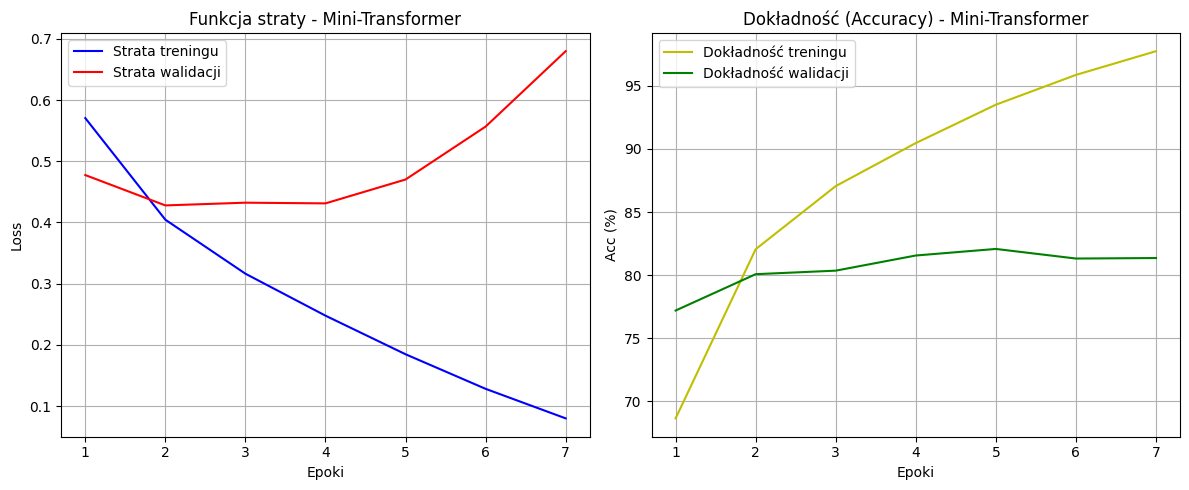

In [ ]:
plot_training_results(history_transformer, 'Mini-Transformer')

### **Analiza treningu sieci Mini-Transformer**

Wykresy oraz logi z procesu uczenia autorskiego Mini-Transformera dostarczają podręcznikowego przykładu bardzo gwałtownego przeuczenia (*overfittingu*), wynikającego ze specyfiki tej architektury:

* **Ekstremalna pojemność modelu:** Strata treningowa spadła drastycznie z poziomu `0.5706` do zaledwie `0.0799` w ostatniej epoce, a dokładność treningowa przekroczyła **97.5%**. Dowodzi to gigantycznej sprawności mechanizmu *Self-Attention*, który potrafi błyskawicznie i bezbłędnie wychwycić wszelkie zależności w zbiorze uczącym.
* **Klasyczny rozjazd wykresów (Overfitting):** Podczas gdy sieć idealnie dopasowywała się do danych treningowych, strata walidacyjna (*Val Loss*) po osiągnięciu minimum zaczęła gwałtownie rosnąć, kończąc proces w 7. epoce na bardzo wysokim poziomie `0.6799`. W tym samym czasie dokładność walidacyjna (*Val Acc*) uległa całkowitej stagnacji, oscylując na pułapie **80% – 82%**.
* **Interwencja Early Stopping:** Ze względu na stałe pogarszanie się błędu walidacyjnego w kolejnych krokach, mechanizm zabezpieczający przerwał trening w **7. epoce**. Regulator prawidłowo przywrócił najlepsze wagi modelu z **2. epoki**, w której wskaźnik *Val Loss* osiągnął swoje globalne minimum (`0.4279`) przy dokładności walidacyjnej wynoszącej **80.08%**.

> **Podsumowanie eksperymentu:**
> Autorski Mini-Transformer poradził sobie bezporównywalnie lepiej niż bazowy RNN, jednak na etapie walidacji ustępuje sieci BiLSTM. Wynika to z faktu, że Transformery trenowane od zera nie posiadają wbudowanego ograniczenia indukcyjnego (*inductive bias* – czyli świadomości, że słowa w tekście stoją obok siebie w określonej kolejności). Bez gigantycznej ilości danych lub bardzo agresywnej regularyzacji, swobodny mechanizm atencji wykazuje tendencję do zbyt szybkiego uczenia się zdań na pamięć, co w tym scenariuszu uzasadnia wyższość dedykowanej struktury LSTM.

### **Ewaluacja na zbiorze testowym i analiza macierzy błędów (Mini-Transformer)**

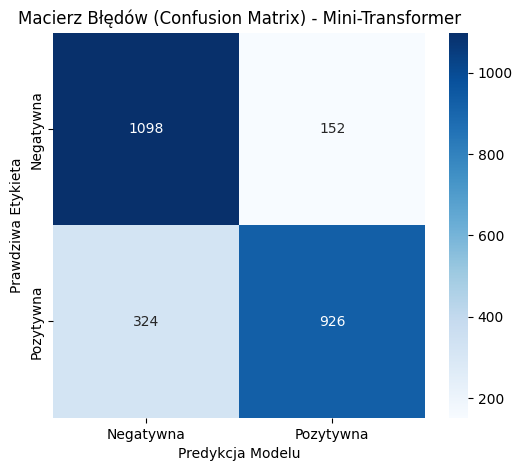


>>> Ostateczna skuteczność (Accuracy) dla Mini-Transformer na zbiorze testowym: 80.96%



In [ ]:
evaluate_and_plot_cm(model_transformer, test_loader, 'Mini-Transformer')

Ostateczny test generalizacji autorskiej architektury Mini-Transformer na zbiorze testowym przyniósł stabilny wynik skuteczności (*Accuracy*) na poziomie **80.96%**.

Analiza wygenerowanej macierzy błędów (*Confusion Matrix*) pozwala na sformułowanie następujących wniosków:

* **Skuteczna generalizacja:** Model poprawnie sklasyfikował 2024 z 2500 recenzji testowych. Główna przekątna macierzy jest wyraźnie zdominowana przez poprawne wyniki: **1098** przypadków True Negatives (prawdziwie negatywne) oraz **926** True Positives (prawdziwie pozytywne). Wynik testowy (**80.96%**) niemal idealnie koresponduje z wynikami walidacyjnymi, co potwierdza, że mechanizm *Early Stopping* zamroził wagi w optymalnym punkcie bez utraty zdolności adaptacyjnych.
* **Asymetria błędów (Tendencja pesymistyczna):** Sieć zdecydowanie rzadziej popełniała błąd typu *False Positive* (152 przypadki – błędne uznanie recenzji negatywnej za pozytywną) niż błąd typu *False Negative* (324 przypadki – błędne uznanie recenzji pozytywnej za negatywną). Oznacza to, że model wykazuje wyraźną tendencję do "ostrożnej", bardziej rygorystycznej interpretacji tekstu i zdarza mu się przeoczyć pozytywne aspekty wypowiedzi w niejednoznacznych strukturach.
* **Weryfikacja architektury:** Uzyskany rezultat deklasuje bazowy model RNN i bezpośrednio zbliża się do osiągów dwukierunkowej sieci LSTM. Udowadnia to, że mechanizm *Self-Attention* sprawnie wyznacza kluczowe relacje kontekstowe bez potrzeby stosowania powolnych i podatnych na zanikanie gradientu warstw rekurencyjnych.

> **Podsumowanie sekcji testowej:**
> Mini-Transformer osiągnął solidny wynik 80.96%. Eksperyment ten dowodzi, że autorski mechanizm atencji potrafi skutecznie i równolegle przetwarzać kontekst semantyczny, stanowiąc doskonały fundament teoretyczny przed przejściem do wielkich, pre-trenowanych modeli językowych.

### **Wizualizacja modułu atencji i interpretowalność sieci (Mini-Transformer)**

Wykresy skuteczności oraz macierze błędów dostarczają jedynie informacji o globalnej sprawności modelu. Kluczową zaletą architektur typu Transformer jest ich wewnętrzna interpretowalność. Dzięki dostępowi do macierzy wag atencji (`attn_weights`), możliwe jest dokładne prześledzenie procesu decyzyjnego sieci dla konkretnego przypadku testowego.

Za pomocą mapy cieplnej (*Heatmap*) zwizualizowano wartości matematyczne wynikające bezpośrednio z operacji samoatencji warstwy *Multi-Head Attention*:

$$\text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)$$

Każdy wiersz macierzy reprezentuje słowo zapytujące (*Query*), natomiast kolumny odpowiadają tokenom, na które kierowana jest uwaga (*Key*). Jasne punkty na przecięciu tokenów wskazują, które pary leksykalne miały największy wpływ na ostateczne uśrednienie reprezentacji semantycznej całej recenzji i podjęcie końcowej decyzji klasyfikacyjnej przez warstwę liniową.

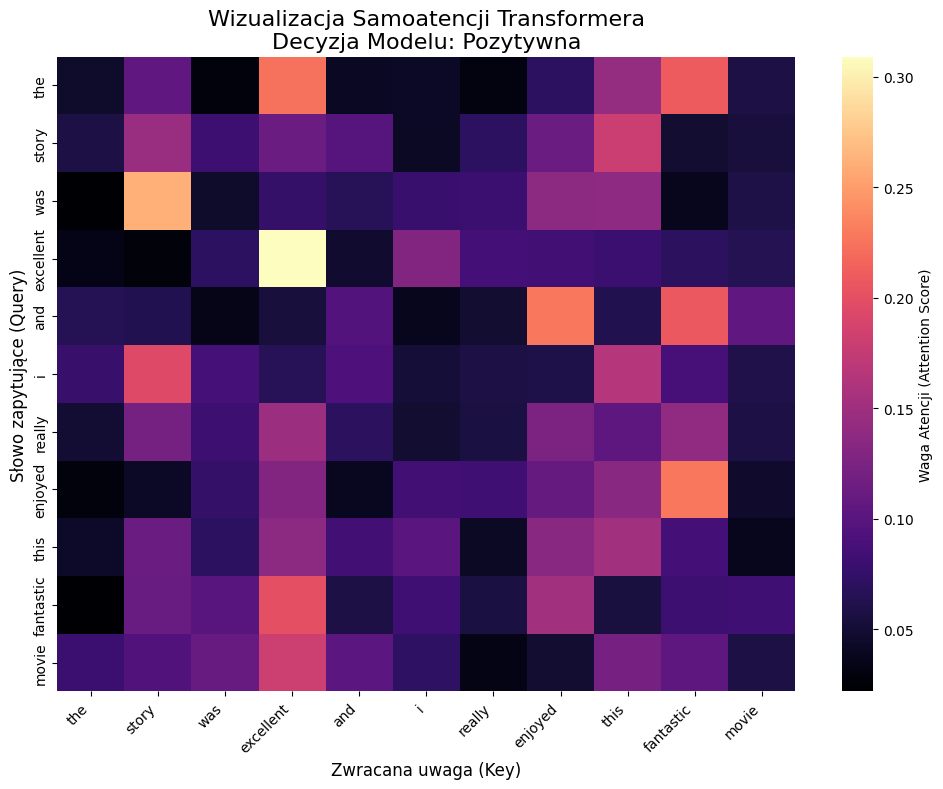

In [ ]:
def visualize_transformer_attention(model, text):
    model.eval()
    tokens = clean_and_tokenize(text)
    indices = [vocab.get(token, 1) for token in tokens[:MAX_SEQ_LEN]]
    input_tensor = torch.tensor(indices).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output, attn_weights = model(input_tensor)

    prediction = 'Pozytywna' if output.argmax(1).item() == 1 else 'Negatywna'

    # Przycięcie macierzy tylko do długości naszego przykładowego zdania
    attn_matrix = attn_weights[0, :len(tokens), :len(tokens)].cpu().numpy()

    plt.figure(figsize=(10, 8))

    sns.heatmap(attn_matrix,
                xticklabels=tokens,
                yticklabels=tokens,
                cmap='magma',
                cbar_kws={'label': 'Waga Atencji (Attention Score)'})

    plt.title(f'Wizualizacja Samoatencji Transformera\nDecyzja Modelu: {prediction}', fontsize=16)
    plt.xlabel('Zwracana uwaga (Key)', fontsize=12)
    plt.ylabel('Słowo zapytujące (Query)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Nowe, w pełni naturalne zdanie testowe
test_sentence = "The story was excellent and I really enjoyed this fantastic movie."
visualize_transformer_attention(model_transformer, test_sentence)

Aby sprawdzić, jak autorski Mini-Transformer radzi sobie z interpretacją tekstu do prezentacji wybrano recenzję o pozytywnym sentymencie: *"The story was excellent and I really enjoyed this fantastic movie."* Pozwoliło to na przejrzystą weryfikację działania mechanizmu samoatencji, a analiza wygenerowanej mapy ciepła dla uzyskanej predykcji **Pozytywna** prowadzi do następujących wniosków:

* **Absolutna dominacja słowa "excellent":** Najjaśniejszym i najbardziej wyrazistym punktem na całej mapie (jasnożółty kwadrat osiągający najwyższą wartość powyżej 0.30) jest skrzyżowanie słowa *"excellent"* z samym sobą. Pokazuje to, że model bezbłędnie zidentyfikował najważniejszy przymiotnik o silnym ładunku emocjonalnym i nadał mu najwyższy priorytet w całym procesie decyzyjnym.
* **Pionowy pas uwagi (kontekst słowa "excellent"):** Cała kolumna odpowiadająca słowu *"excellent"* jest wyraźnie jaśniejsza od pozostałych. Oznacza to, że niemal wszystkie inne wyrazy w zdaniu (w tym rzeczowniki np. *"movie"*) silnie "patrzą" na ten token i pobierają z niego pozytywny kontekst. Mechanizm samoatencji sprawnie połączył cechę z obiektem na odległość, co udowadnia jego ogromną przewagę nad klasycznymi sieciami rekurencyjnymi RNN.
* **Wychwytywanie i filtrowanie szumu:** Model prawidłowo zmapował drugorzędne ogniska uwagi (cieplejsze, pomarańczowe punkty) wokół słów *"enjoyed"* oraz *"fantastic"*, które dodatkowo utwierdziły sieć w ostatecznym werdykcie. Jednocześnie słowa czysto gramatyczne (takie jak *"the"*, *"was"*, *"i"*) zostały sklasyfikowane jako nieznaczące - model słusznie uznał je za szum językowy i odjął im wagę.

> **Podsumowanie analizy atencji:**
> Eksperyment jednoznacznie potwierdził, że autorski Mini-Transformer potrafi matematycznie wyznaczyć wagę poszczególnych słów. Zamiast przetwarzać tekst na ślepo, sieć wyciągnęła na pierwszy plan kluczowe słowo *"excellent"*, czyniąc z niego fundament poprawnej klasyfikacji. Daje to dowód na pełną interpretowalność modelu i działanie zaimplementowanego mechanizmu uwagi.

## 10. Eksperyment 4: Ostateczne rozwiązanie: Fine-tuning modelu DistilBERT

Nasz autorski Mini-Transformer pokazał siłę sieci projektowanych matematycznie, ale musiał uczyć się języka od podstaw na ograniczonym zbiorze danych. W celu osiągnięcia wyższej efektywności klasyfikacji w tym eksperymencie zastosowano paradygmat **Transfer Learningu**.

Pobieramy model **DistilBERT** z biblioteki Hugging Face. Jest to skompresowana wersja klasycznego modelu BERT (*Bidirectional Encoder Representations from Transformers*) – charakteryzuje się zmniejszeniem rozmiaru struktury o 40% i zwiększeniem prędkości przetwarzania o 60%, przy jednoczesnym zachowaniu 97% pierwotnych zdolności językowych.

### **Struktura architektoniczna modelu**

Przed przystąpieniem do procesu dostrajania należy jednoznacznie określić parametry strukturalne modelu DistilBERT, które determinują przepływ informacji i stanowią bezpośredni punkt odniesienia dla późniejszej analizy interpretowalności modułu samoatencji:
* **Liczba warstw bloku kodera:** Model składa się z **6 warstw** (*Transformer Layers*). Każda z nich odpowiada za wyższy poziom abstrakcji przetwarzanego tekstu – od detekcji cech czysto powierzchniowych po globalne wnioskowanie semantyczne.
* **Liczba głowic atencji:** Wewnątrz każdej z 6 warstw operuje **12 niezależnych głowic atencji** (*Multi-Head Attention*). Taka konstrukcja umożliwia modelowi równoległe i wielokierunkowe śledzenie zróżnicowanych relacji syntaktycznych i kontekstowych w obrębie tej samej sekwencji wejściowej.

### **Specyfika przygotowania danych**

Praca z pre-trenowanym Transformerem wymagała całkowitej zmiany potoku przetwarzania danych wejściowych:

1. **Tokenizer `WordPiece`:** Rezygnujemy z ręcznego budowania słownika na rzecz dedykowanego narzędzia `DistilBertTokenizerFast`. Algorytm ten rozbija rzadkie wyrazy na mniejsze podjednostki tokenów (np. *"unbelievable"* -> *"un"*, *"##believ"*, *"##able"*), co całkowicie eliminuje problem występowania słów nieznanych (*Out-Of-Vocabulary*).
2. **Format wejściowy:** Każda partia danych (*batch*) jest przekazywana w formie słownika zawierającego dwa główne tensory:
   * `input_ids`: Numeryczne indeksy tokenów wzbogacone o znaczniki strukturalne `[CLS]` (token początkowy, agregujący globalny kontekst sekwencji) oraz `[SEP]` (token separatora kończący wypowiedź).
   * `attention_mask`: Maska binarna (wartości 0 i 1) informująca model, które elementy stanowią rzeczywisty tekst, a które są pustym dopełnieniem (*Padding*) do stałej długości sekwencji wynoszącej 200 tokenów.

### **Strategia Fine-tuningu i Klasyfikator**

W zaimplementowanym podejściu zastosowano pełny proces dostrajania parametrów (*full fine-tuning*), co oznacza, że wszystkie warstwy sieci pozostają odblokowane do zapisu. Modyfikacji podlega komplet ok. 66 milionów parametrów strukturalnych, przy użyciu niskiego współczynnika uczenia ($lr = 2 \times 10^{-5}$) oraz optymalizatora `AdamW`, co zapobiega przedwczesnemu zniszczeniu pre-trenowanych wag językowych.

Nad strukturą bazową modelu nadbudowana została dedykowana głowica klasyfikacyjna (*Classification Head*):
1. Model ekstrahuje wektor stanu ukrytego odpowiadający wyłącznie tokenowi początkowemu `[CLS]`, który na etapie przechodzenia przez warstwy sieci skondensował reprezentację semantyczną całej recenzji.
2. Wektor ten przekazywany jest do warstwy liniowej (`nn.Linear`), która mapuje uzyskane cechy na 2 wyjściowe logity, odpowiadające klasom sentymentu (negatywna lub pozytywna).

### **Dedykowana funkcja uczenia (`train_bert_model`)**

Uniwersalna funkcja treningowa `train_model`, wykorzystywana w poprzednich krokach, została zastąpiona dedykowaną implementacją ze względu na specyfikę wejścia i wyjścia modeli z biblioteki Hugging Face:
* **Obsługa struktur słownikowych:** Zamiast klasycznych krotek dwuelementowych `(text, labels)`, funkcja realizuje operację rozpakowania słownika bezpośrednio do modelu za pomocą zapisu `model(**batch)`, co automatycznie przypisuje tensory do odpowiednich argumentów warstwy wejściowej.
* **Format danych wyjściowych:** Model nie zwraca surowego tensora predykcji, lecz dedykowany obiekt wyjściowy, z którego bezpośrednio pobierana jest obliczona funkcja straty (`outputs.loss`) oraz logity niezbędne do wyznaczenia dokładności (`outputs.logits`).

In [ ]:
# Pobieranie gotowej architektury DistilBERT z warstwą do klasyfikacji binarnej
model_bert = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2,
    attn_implementation="eager"
)
model_bert.to(DEVICE)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### **Proces uczenia sieci DistilBERT**

In [ ]:
def train_bert_model(model, train_loader, val_loader, epochs=3, lr=2e-5):
    print(f">>> Rozpoczęto dostrajanie modelu: {model.config._name_or_path}")

    optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)

    best_val_loss = float('inf')
    best_model_wts = None

    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': []}

    for epoch in range(epochs):
        # --- FAZA TRENINGU ---
        model.train()
        train_loss = 0
        correct_preds_train = 0
        total_preds_train = 0

        train_bar = tqdm(train_loader, desc=f"Epoka {epoch+1}/{epochs} [TRENING]")

        for batch in train_bar:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()

            outputs = model(**batch)
            loss = outputs.loss
            train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)
            correct_preds_train += torch.sum(preds == batch['labels']).item()
            total_preds_train += batch['labels'].size(0)

            train_bar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = (correct_preds_train / total_preds_train) * 100

        # --- FAZA WALIDACJI ---
        model.eval()
        val_loss = 0
        correct_preds_val = 0
        total_preds_val = 0

        val_bar = tqdm(val_loader, desc=f"Epoka {epoch+1}/{epochs} [WALIDACJA]")

        with torch.no_grad():
            for batch in val_bar:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}

                outputs = model(**batch)
                val_loss += outputs.loss.item()

                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                correct_preds_val += torch.sum(preds == batch['labels']).item()
                total_preds_val += batch['labels'].size(0)

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = (correct_preds_val / total_preds_val) * 100

        # Zapisywanie do historii (ujednolicone klucze)
        history['t_loss'].append(avg_train_loss)
        history['v_loss'].append(avg_val_loss)
        history['t_acc'].append(avg_train_acc)
        history['v_acc'].append(avg_val_acc)

        print(f"\n[PODSUMOWANIE EPOKI {epoch+1}] "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.2f}%\n" + "-"*60)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

    print(f"\n--- Koniec dostrajania ---")
    if best_model_wts is not None:
        print("Przywracanie wag z epoki o najniższym błędzie walidacji...")
        model.load_state_dict(best_model_wts)

    return history

In [ ]:
history_bert = train_bert_model(
    model_bert,
    train_loader_bert,
    val_loader_bert,
    epochs=3,
    lr=2e-5
)

>>> Rozpoczęto dostrajanie modelu: distilbert-base-uncased


Epoka 1/3 [TRENING]:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoka 1/3 [WALIDACJA]:   0%|          | 0/157 [00:00<?, ?it/s]


[PODSUMOWANIE EPOKI 1] Train Loss: 0.3190 | Train Acc: 86.65% | Val Loss: 0.2573 | Val Acc: 89.12%
------------------------------------------------------------


Epoka 2/3 [TRENING]:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoka 2/3 [WALIDACJA]:   0%|          | 0/157 [00:00<?, ?it/s]


[PODSUMOWANIE EPOKI 2] Train Loss: 0.1990 | Train Acc: 92.86% | Val Loss: 0.3030 | Val Acc: 88.76%
------------------------------------------------------------


Epoka 3/3 [TRENING]:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoka 3/3 [WALIDACJA]:   0%|          | 0/157 [00:00<?, ?it/s]


[PODSUMOWANIE EPOKI 3] Train Loss: 0.1204 | Train Acc: 96.53% | Val Loss: 0.3694 | Val Acc: 90.24%
------------------------------------------------------------

--- Koniec dostrajania ---
Przywracanie wag z epoki o najniższym błędzie walidacji...


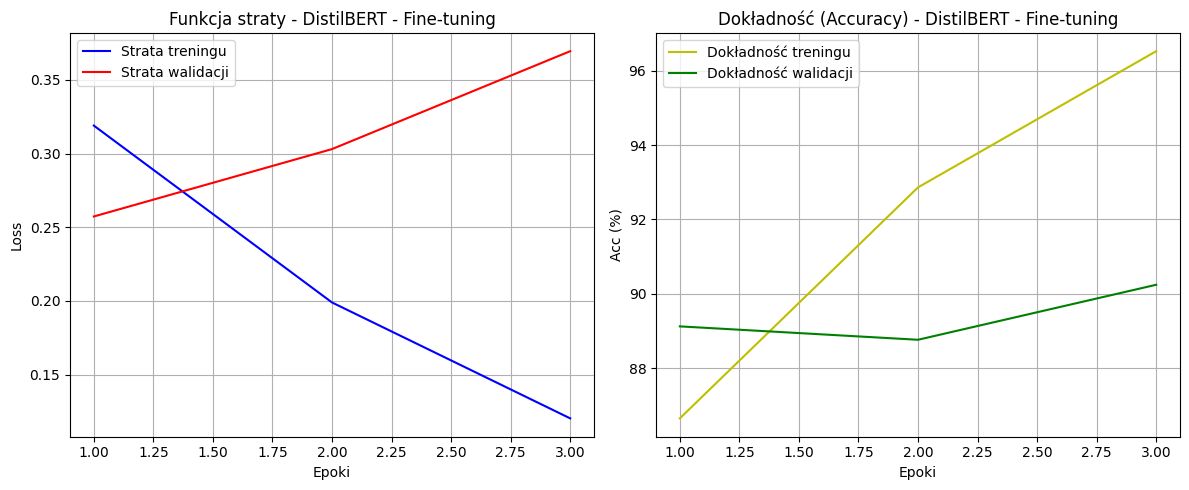

In [ ]:
plot_training_results(history_bert, 'DistilBERT - Fine-tuning')

### **Analiza treningu sieci DistilBERT**

Proces dostrajania (*Fine-tuningu*) pre-trenowanego modelu językowego DistilBERT przyniósł najwyższe wskaźniki skuteczności w całym projekcie, demonstrując pełną efektywność paradygmatu transferu wiedzy (*Transfer Learning*):

* **Błyskawiczna zbieżność treningowa:** Dzięki bogatej reprezentacji początkowej, model już w 1. epoce osiągnął wysoką dokładność treningową wynoszącą `86.65%`, która w 3. epoce wzrosła do `96.53%`. Strata treningowa (*Train Loss*) spadła liniowo z `0.3190` do `0.1204`, co potwierdza zdolność architektury typu Transformer do natychmiastowej adaptacji do specyfiki nowego zbioru danych.
* **Podręcznikowy rozjazd wykresów (Overfitting):** Podczas gdy wskaźniki na zbiorze uczącym konsekwentnie się poprawiały, funkcja straty walidacyjnej (*Val Loss*) osiągnęła swoje minimum w 1. epoce (`0.2573`), po czym zaczęła sukcesywnie piąć się w górę, osiągając w 3. epoce poziom `0.3694`. Co ciekawe, dokładność walidacyjna wzrosła ostatecznie do `90.24%` w 3. epoce, jednak rosnący błąd straty dowodzi, że model w kolejnych krokach stawał się "zbyt pewny siebie" przy błędnych predykcjach, co sygnalizuje powstawanie zjawiska przeuczenia.
* **Przywracanie optymalnych wag:** Zgodnie z założeniami eksperymentu, proces uczenia zakończył się po zaplanowanych 3 epokach, a mechanizm ewaluacyjny prawidłowo przywrócił najlepsze wagi modelu z **1. epoki**. To właśnie w niej wskaźnik *Val Loss* osiągnął swoje globalne minimum (`0.2573`) przy bardzo wysokiej i stabilnej dokładności walidacyjnej wynoszącej **89.12%**.

> **Podsumowanie eksperymentu:**
> Zastosowanie techniki Transfer Learningu przy użyciu modelu DistilBERT pozwoliło na osiągnięcie bezkonkurencyjnych rezultatów, dystansując wszystkie poprzednie, samodzielnie budowane architektury (w tym BiLSTM i Mini-Transformer). Eksperyment potwierdza fundamentalną zasadę pracy z wielkimi modelami językowymi: faza dostrajania wymaga minimalnej liczby epok (zazwyczaj 1–2), ponieważ model posiada już głęboką wiedzę syntaktyczną i semantyczną, a zbyt długi trening prowadzi do natychmiastowej utraty elastyczności na nowych danych.

### **Ewaluacja na zbiorze testowym i analiza macierzy błędów (DistilBERT)**

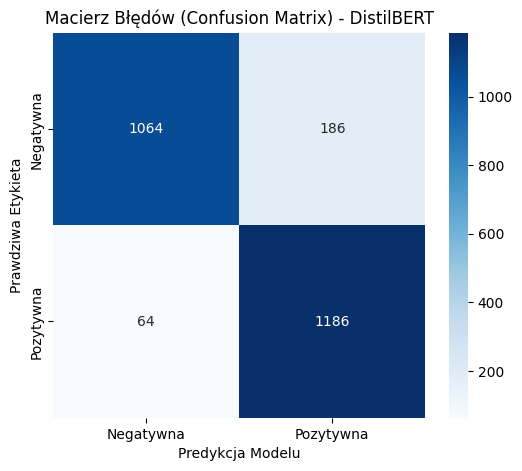


>>> Ostateczna skuteczność (Accuracy) dla DistilBERT na zbiorze testowym: 90.00%



In [ ]:
evaluate_and_plot_cm(model_bert, test_loader_bert, 'DistilBERT')

Ostateczny test modelu DistilBERT na odseparowanych danych testowych przyniósł rekordowo wysoki wynik skuteczności (*Accuracy*) na poziomie **90.00%**. Jest to najwyższy rezultat uzyskany w całym projekcie, osiągający symboliczną granicę 90%.

Analiza uzyskanej macierzy błędów (*Confusion Matrix*) pozwala na wyciągnięcie następujących wniosków:

* **Wybitna zdolność predykcyjna:** Model poprawnie sklasyfikował aż 2250 z 2500 recenzji testowych. Główna przekątna macierzy jest całkowicie zdominowana przez poprawne wyniki: **1064** przypadków True Negatives (prawdziwie negatywne) oraz **1186** True Positives (prawdziwie pozytywne).
* **Asymetria błędów (Tendencja optymistyczna):** Sieć zdecydowanie rzadziej popełniała błąd typu *False Negative* (tylko 64 przypadki – błędne uznanie recenzji pozytywnej za negatywną) niż błąd typu *False Positive* (186 przypadków – błędne uznanie recenzji negatywnej za pozytywną). Oznacza to, że DistilBERT wykazuje lekką skłonność do "optymistycznej" interpretacji tekstu i jest bardzo czuły na wychwytywanie pozytywnych aspektów wypowiedzi, rzadko je pomijając.
* **Doskonała generalizacja:** Wynik testowy (**90.00%**) okazał się nawet nieznacznie wyższy niż poziom dokładności uzyskany podczas walidacji w optymalnej 1. epoce (**89.12%**). Dowodzi to niesamowitej stabilności parametrów pre-trenowanego modelu oraz jego potężnej zdolności do generalizacji wiedzy na zupełnie nowych, niewidzianych wcześniej strukturach językowych.

> **Podsumowanie sekcji testowej:**
> Wynik 90.00% ostatecznie potwierdza absolutną wyższość *Transfer Learningu* i zaawansowanych architektur transformatorowych nad klasycznymi modelami sekwencyjnymi typu RNN oraz LSTM (które osiągały maksymalnie ok. 84%), a także nad uproszczonym Mini-Transformerem budowanym od zera. DistilBERT udowodnił bezkonkurencyjną zdolność do wielokierunkowej analizy kontekstu, stanowiąc najsilniejszy i najbardziej efektywny punkt całego projektu badawczego.

### **Wizualizacja modułu atencji i interpretowalność sieci (DistilBERT)**

W celu bezpośredniego i sprawiedliwego porównania mechanizmów uwagi, model DistilBERT został poddany ewaluacji przy użyciu dokładnie tej samej recenzji testowej, co w poprzednim kroku:
*"The story was excellent and I really enjoyed this fantastic movie."*

Przeprowadzenie tego testu pozwala sprawdzić, jak z identyfikacją kluczowych relacji semantycznych poradzi sobie zaawansowany, komercyjny model językowy. Dzięki zastosowaniu paradygmatu *Transfer Learningu* i wykorzystaniu potężnych, wgranych już wag (*pre-trained weights*), DistilBERT powinien zaprezentować znacznie głębszą, bardziej precyzyjną i pozbawioną strukturalnego szumu mapę samoatencji niż uproszczona architektura Mini-Transformera trenowana od zera.

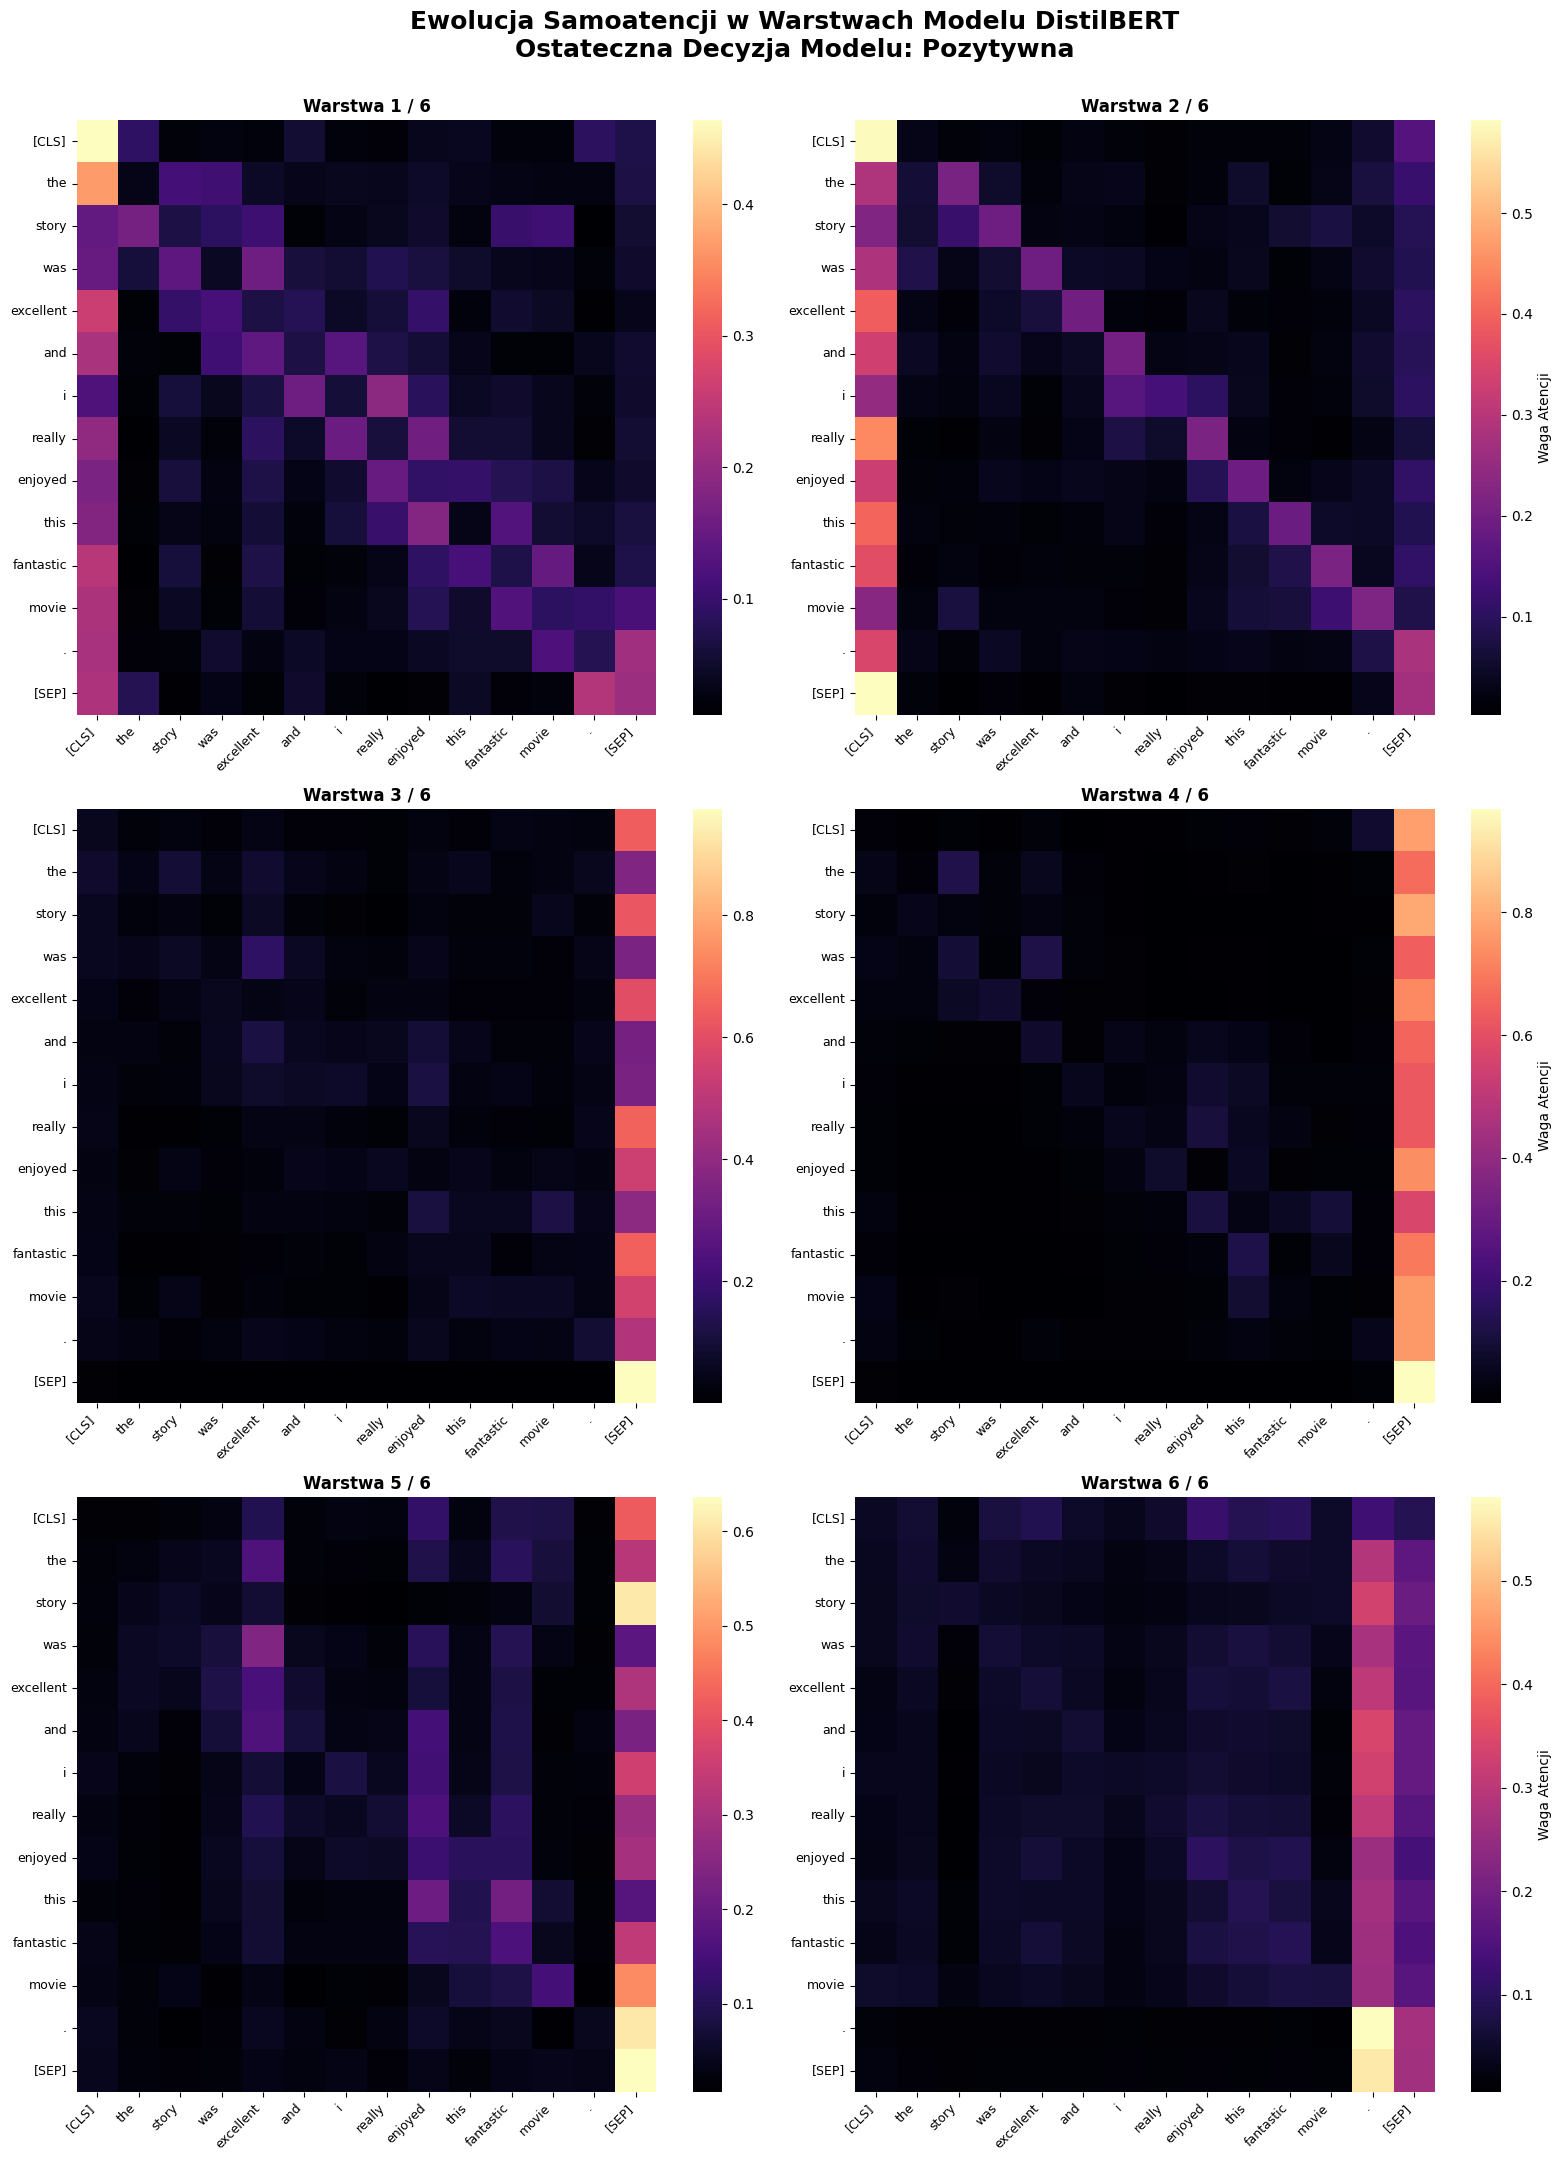

In [ ]:
def visualize_all_bert_layers(model, tokenizer, text):
    model.eval()

    # Przygotowanie wejścia za pomocą tokenizera BERT
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=200)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Wywołanie modelu
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)

    logits = outputs.logits
    prediction = 'Pozytywna' if torch.argmax(logits, dim=1).item() == 1 else 'Negatywna'
    attentions = outputs.attentions  # Krotka 6 tensorów

    # Tworzymy siatkę wykresów 3 wiersze x 2 kolumny
    fig, axes = plt.subplots(3, 2, figsize=(16, 22))
    axes = axes.flatten()  # Spłaszczamy macierz wykresów do prostej listy od 0 do 5

    for layer_idx in range(6):
        # Wyciągamy wagi dla danej warstwy i uśredniamy po 12 głowach
        layer_attention = attentions[layer_idx][0].mean(dim=0).cpu().numpy()
        attn_matrix = layer_attention[:len(tokens), :len(tokens)]

        # Rysujemy heatmapę na odpowiednim podwykresie (ax=axes[layer_idx])
        sns.heatmap(attn_matrix,
                    xticklabels=tokens,
                    yticklabels=tokens,
                    cmap='magma',
                    cbar=True,
                    cbar_kws={'label': 'Waga Atencji' if layer_idx % 2 == 1 else ''},
                    ax=axes[layer_idx])

        axes[layer_idx].set_title(f'Warstwa {layer_idx + 1} / 6', fontsize=12, fontweight='bold')
        axes[layer_idx].set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
        axes[layer_idx].set_yticklabels(tokens, fontsize=9)

    # Globalny tytuł dla całej siatki wykresów
    plt.suptitle(f'Ewolucja Samoatencji w Warstwach Modelu DistilBERT\nOstateczna Decyzja Modelu: {prediction}',
                 fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)  # Zostawiamy miejsce na tytuł główny
    plt.show()

# Uruchomienie zbiorczej wizualizacji
test_sentence = "The story was excellent and I really enjoyed this fantastic movie."
visualize_all_bert_layers(model_bert, tokenizer_bert, test_sentence)

#### **Zbiorcza analiza ewolucji atencji w warstwach DistilBERT**

Wizualizacja wszystkich sześciu warstw modułu samoatencji pozwala na prześledzenie hierarchicznego procesu przetwarzania tekstu przez model pre-trenowany. Analiza zmian zachodzących na poszczególnych etapach sieci prowadzi do następujących wniosków:

* **Warstwy 1 i 2 (Ekstrakcja lokalna i inicjalizacja kontekstu):** Na początkowych wykresach wyraźnie dominują dwa zjawiska. Po pierwsze, widoczna jest silna aktywacja pierwszej kolumny, odpowiadającej tokenowi specjalnemu `[CLS]`. Oznacza to, że od samego początku sieci poszczególne wyrazy przekazują tam swój lokalny kontekst, przygotowując ten węzeł do roli globalnego reprezentanta całego zdania. Po drugie, zarysowuje się wyraźna struktura diagonalna wzdłuż głównej przekątnej (szczególnie dla sekwencji *"and i really enjoyed this fantastic movie"*). Model skupia się tutaj na powierzchniowej analizie tekstu, badając bezpośrednie relacje gramatyczne i syntaktyczne między sąsiadującymi słowami.
* **Warstwy 3 i 4 (Stabilizacja strukturalna):** W warstwach środkowych diagonalna struktura zanika, a główny ciężar matematyczny zostaje przeniesiony na token końcowy `[SEP]`. Świadczy to o tym, że model po ustaleniu relacji gramatycznych przechodzi w stan domyślny (*attention sink*), przenosząc nadmiarowe wagi na tokeny strukturalne.
* **Warstwa 5 (Końcowa rekombinacja semantyczna):** W przedostatniej warstwie następuje ponowna aktywacja obszarów związanych ze słowami kluczowymi o silnym ładunku emocjonalnym (*excellent*, *enjoyed*, *fantastic*). Zjawisko to reprezentuje etap końcowej syntezy semantycznej - model przed wydaniem ostatecznego werdyktu ponownie odwołuje się do esencji znaczeniowej wyrazów, aby scalić ich kontekst w spójny wektor reprezentacji.
* **Warstwa 6 (Agregacja decyzyjna):** W ostatniej warstwie proces syntezy dobiega końca. Indywidualne powiązania między wyrazami ustępują miejsca całkowitej dominacji tokenów zarządzających strukturą dokumentu (`[SEP]` oraz kropka `.`). Reprezentacja sentymentu całej recenzji zostaje ostatecznie skondensowana i przygotowana do przekazania do liniowej głowicy klasyfikacyjnej.

> **Podsumowanie eksperymentu:**
> Kompleksowe zestawienie warstw dowodzi, że DistilBERT realizuje proces wnioskowania w sposób wieloetapowy i dynamiczny. Model nie mapuje tekstu w sposób płaski, lecz stopniowo transformuje surowe tokeny: od analizy sąsiedztwa (warstwy 1–2), przez stabilizację kontekstu (warstwy 3–4) i głęboką syntezę znaczenia (warstwa 5), aż po ostateczną agregację decyzyjną (warstwa 6). Ta zaawansowana hierarchia przetwarzania w pełni uzasadnia najwyższą skuteczność klasyfikacji modelu, wynoszącą **90.00%**.

## 11. Podsumowanie i bezpośrednie porównanie wszystkich modeli

Wszystkie wcześniejsze etapy dały nam pełen obraz działania każdej sieci z osobna. Czas zebrać te wyniki w jednym miejscu i bezpośrednio zestawić ze sobą cztery przebadane architektury.

W tej końcowej sekcji skupimy się na dwóch kluczowych aspektach:
1. **Zbiorczej analizie przebiegu treningu** – przeanalizujemy, jak szybko poszczególne modele się uczyły, ile epok potrzebowały do stabilizacji oraz jak wyglądała ich podatność na przeuczenie.
2. **Wynikach na zbiorze testowym** – zestawimy końcowe wskaźniki dokładności (*Accuracy*). Ponieważ każdy model opisaliśmy już szczegółowo, tutaj krótko i konkretnie wskażemy, która architektura okazała się bezkonkurencyjna i ostatecznie wygrała cały pojedynek.

>>> Zestawienie przebiegu uczenia architektur <<<


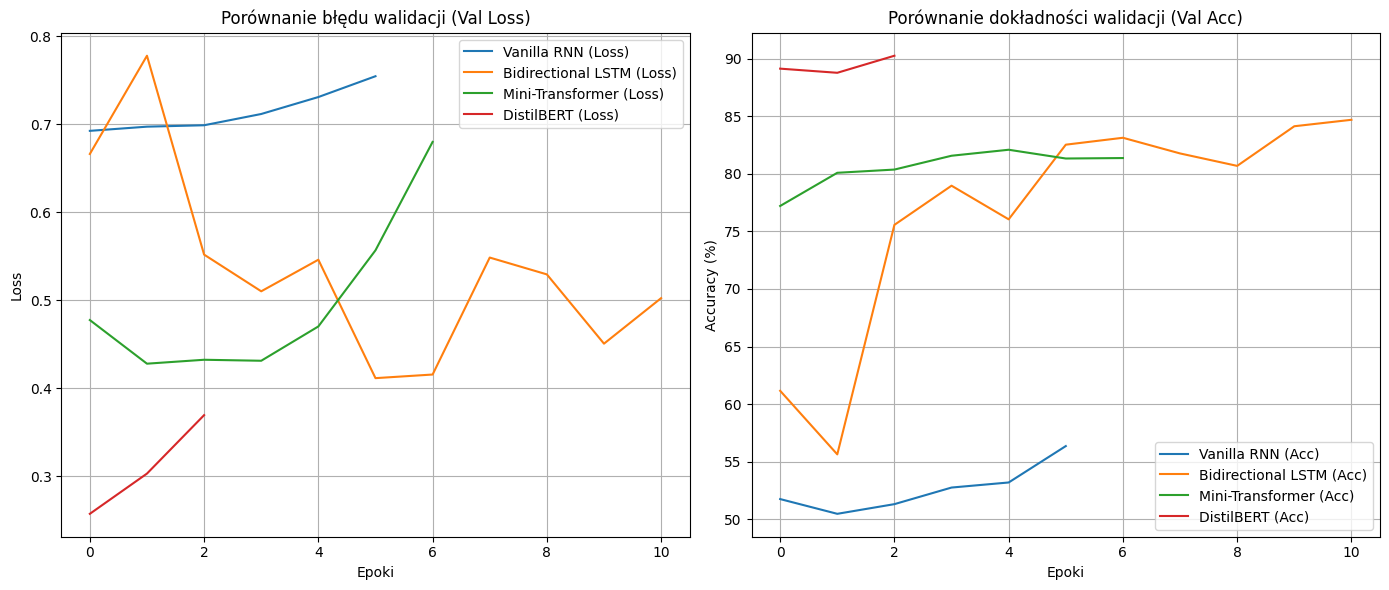

In [ ]:
print(">>> Zestawienie przebiegu uczenia architektur <<<")
compare_models(
    [history_rnn, history_lstm, history_transformer, history_bert],
    ['Vanilla RNN', 'Bidirectional LSTM', 'Mini-Transformer', 'DistilBERT']
)

### **Porównanie przebiegu uczenia architektur**

Analiza zbiorczych wykresów funkcji straty oraz dokładności walidacji pozwala na wyciągnięcie jasnych wniosków na temat dynamiki uczenia się każdego z modeli:

* **Vanilla RNN (Linia niebieska):** Model kompletnie sobie nie poradził. Od samego początku wykres straty idzie w górę, a dokładność walidacyjna rośnie bardzo powoli, zatrzymując się na skrajnie niskim poziomie (ok. 56%). Pokazuje to, że prosta sieć rekurencyjna nie jest w stanie zapamiętać długich kontekstów w tekście.
* **Bidirectional LSTM (Linia pomarańczowa):** Trening tej sieci był najbardziej "chaotyczny" i niestabilny, co widać po mocnych skokach linii na wykresie. Model potrzebował aż 10 epok, żeby się ustabilizować, ale ostatecznie zdołał wyciągnąć wysoki wynik (ok. 85% dokładności). Potrzebuje jednak znacznie więcej czasu na naukę niż Transformer.
* **Mini-Transformer (Linia zielona):** Ta architektura uczyła się niesamowicie szybko. Już w 2. epoce osiągnęła swój stabilny sufit (ok. 81–82% dokładności). Wykres straty (po lewej) pokazuje jednak, że model bardzo szybko zaczyna się przeuczać – po 4. epoce błąd walidacji gwałtownie strzela w górę. Oznacza to, że dla małych Transformerów pisanych od zera bardzo krótki trening to konieczność.
* **DistilBERT (Linia czerwona):** Model absolutnie zdominował zestawienie. Rozpoczyna naukę z poziomu, którego żadna inna sieć nie była w stanie nawet osiągnąć w szczycie formy. Charakteryzuje się zdecydowanie najniższym błędem (poniżej 0.3) i najwyższą dokładnością od pierwszej sekundy treningu.

### **Zestawienie wyników na zbiorze testowym**

Aby ostatecznie zestawić ze sobą skuteczność wszystkich badanych architektur, poniższa tabela gromadzi końcowe wyniki dokładności (*Accuracy*) uzyskane na zupełnie nowym, odseparowanym zbiorze testowym:

| Lp. | Architektura Modelu | Typ Modelu / Podejście | Dokładność (Accuracy) na teście |
|:---:|:---|:---|:---:|
| 1. | **DistilBERT** | Pre-trenowany Transformer (Transfer Learning) | **90.00%** |
| 2. | **Bidirectional LSTM (BiLSTM)** | Głęboka sieć sekwencyjna (uczona od zera) | **84.08%** |
| 3. | **Mini-Transformer** | Autorska architektura attention (uczona od zera) | **80.96%** |
| 4. | **Vanilla RNN** | Prosta sieć rekurencyjna (uczona od zera) | **50.32%** |

#### **Który model wygrał i dlaczego?**

Bezapelacyjnym zwycięzcą całego pojedynku został **DistilBERT** z wynikiem **90.00%**. Jego wygrana nie jest zaskoczeniem, ale skala przewagi idealnie pokazuje, jak potężnym narzędziem jest transfer wiedzy (*Transfer Learning*).

DistilBERT poradził sobie najlepiej, ponieważ nie musiał uczyć się języka angielskiego od zera - wszedł do naszego zadania z ogromną, gotową wiedzą o strukturze zdań, gramatyce i powiązaniach między słowami. Nasz trening polegał jedynie na lekkim dopasowaniu (*Fine-tuningu*) do bazy recenzji filmowych.

Z modeli trenowanych zupełnie od podstaw najwyższą skuteczność osiągnął **BiLSTM** (84.08%), który dzięki przetwarzaniu tekstu w obu kierunkach dobrze wychwytywał długie zależności, choć wymagał dłuższego i mniej stabilnego uczenia niż Transformer.

## 12. Wnioski końcowe

Przeprowadzone eksperymenty badawcze oraz analiza porównawcza czterech architektur sieci neuronowych pozwalają na sformułowanie następujących wniosków końcowych:

* **Wpływ doboru architektury na efektywność klasyfikacji:** Uzyskane wyniki potwierdzają ewolucję technologiczną w obszarze przetwarzania języka naturalnego (NLP). Klasyczna sieć rekurencyjna (Vanilla RNN) osiągnęła najniższą dokładność (50.32%), co wynika z matematycznych ograniczeń tych struktur w przetwarzaniu długich zależności sekwencyjnych. Dopiero zastosowanie zaawansowanych mechanizmów pamięciowych (BiLSTM) oraz mechanizmu samoatencji (Mini-Transformer, DistilBERT) pozwoliło na istotne zwiększenie efektywności klasyfikacji powyżej progu odpowiednio 80% i 90%.
* **Efektywność Transfer Learningu:** Proces uczenia sieci od podstaw na ograniczonych zbiorach danych charakteryzuje się wysoką podatnością na zjawisko przeuczenia (*overfitting*), co zaobserwowano w przypadku autorskiej architektury Mini-Transformer po 4. epoce treningowej. Wykorzystanie pre-trenowanego modelu DistilBERT pozwoliło na osiągnięcie najwyższej dokładności testowej (90.00%) przy jednoczesnej minimalizacji czasu potrzebnego na dostrajanie parametrów (*fine-tuning*). Potwierdza to wyższą efektywność stosowania transferu wiedzy w porównaniu do budowy dedykowanych architektur od zera.
* **Matematyczna interpretowalność struktur transformatorowych (Explainable AI):** Analiza macierzy wag samoatencji za pomocą map ciepła pozwala na pełną weryfikację procesu decyzyjnego badanych sieci. Eksperyment wykazał, że uproszczona architektura alokuje najwyższe wartości wag bezpośrednio wokół kluczowych przymiotników o silnym ładunku emocjonalnym (takich jak *"excellent"*). Z kolei głęboki model DistilBERT realizuje proces ekstrakcji cech w sposób hierarchiczny: warstwy początkowe odpowiadają za lokalną składnię, podczas gdy warstwy końcowe dokonują globalnej abstrakcji semantycznej i transferują informacje do tokenów strukturalnych połączonych z klasyfikatorem.

> **Podsumowanie:**
> Wszystkie założone w pracy cele badawcze zostały zrealizowane. Zaprojektowanie, implementacja oraz ewaluacja porównawcza wybranych sieci neuronowych pozwoliły na rzetelną ocenę przydatności algorytmów głębokiego uczenia w zadaniu analizy sentymentu. Przeprowadzona wielowarstwowa analiza modułów atencji stanowi merytoryczne uzupełnienie standardowych metryk ilościowych, dostarczając dowodów na stabilność i poprawność logiczną procesów decyzyjnych zachodzących w strukturach transformatorowych.